<a href="https://colab.research.google.com/github/mehrerm/TFM/blob/main/notebooks/analisis_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En este notebook se trabajará con el dataset ya depurado listo, se conservarán todas las librerías importadas utilizadas durante el EDA y los que se consideren necesarios.

In [2]:
#Cargo o importo pandas, numpy, Matplotlib,
import pandas as pd
import numpy as np

from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf


from scipy import stats





import requests
import unicodedata
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from statsmodels.regression.mixed_linear_model import MixedLM
!pip install optbinning
from optbinning import OptimalBinning, Scorecard, BinningProcess
from sklearn.linear_model import LogisticRegression
from urllib.parse import quote


#lugar donde se van guardando las figuras
fig_dir = "figuras"
os.makedirs(fig_dir, exist_ok=True)

table_dir = "tablas"
os.makedirs(table_dir, exist_ok=True)


#la url donde están los datos

BASE_URL = "https://raw.githubusercontent.com/mehrerm/TFM/main/data/processed/"
#########################

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.8/214.8 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.1/28.1 MB 53.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 22.9 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled protobuf-5.29.5
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grain 0.2.15 requires protobuf>=5.28.3, but you have protobuf 5.26.1 which is incompatible.
ydf 0.14.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 5.26.1 which is incompatibl

In [3]:
!git clone https://github.com/mehrerm/TFM.git


Cloning into 'TFM'...
remote: Enumerating objects: 488, done.
remote: Counting objects: 100% (120/120), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 488 (delta 72), reused 28 (delta 28), pack-reused 368 (from 2)
Receiving objects: 100% (488/488), 56.51 MiB | 18.57 MiB/s, done.
Resolving deltas: 100% (219/219), done.


In [4]:
#df_merged = pd.read_csv("TFM/data/processed/df_merged.csv")
df_merged = pd.read_csv(BASE_URL + "df_merged.csv")
df = df_merged.copy()
df_merged.head()


,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,Region Name,RTCenters,Linac,Protontherapy,XRay,Brachytherapy,Last Update,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Incidence,2007,61.434111,80.958928,7.865065,3666,Belarus,Eastern Europe,13,31,0,11,17,2024,9563133.0,4450421.0,5112713.0,4735.481076
1,Lung,Male,Incidence,2008,62.729974,84.930604,8.033257,3765,Belarus,Eastern Europe,13,31,0,11,17,2024,9529358.0,4432534.0,5096824.0,6376.175692
2,Lung,Male,Incidence,2009,61.098990,84.106229,7.731976,3719,Belarus,Eastern Europe,13,31,0,11,17,2024,9507337.0,4421224.0,5086114.0,5352.488092
3,Lung,Male,Incidence,2010,62.582334,86.376743,7.914747,3812,Belarus,Eastern Europe,13,31,0,11,17,2024,9490752.0,4412608.0,5078144.0,6034.678852
4,Lung,Male,Incidence,2011,59.755001,83.234410,7.621488,3665,Belarus,Eastern Europe,13,31,0,11,17,2024,9472735.0,4402539.0,5070196.0,6527.659343


In [5]:
#df_merged2022 = pd.read_csv("TFM/data/processed/df_merged2022.csv")
df_merged2022 = pd.read_csv(BASE_URL + "df_merged2022.csv")
df_merged2022.head()

,Cancer label,Sex,Type,Year,ASR (World),Crude rate,Cumulative risk,Total,Country_harmonized,Region Name,RTCenters,Linac,Protontherapy,XRay,Brachytherapy,Last Update,Population,Population_male,Population_female,GDP_per_capita
0,Lung,Male,Mortality,2022,20.689747,50.979249,2.350679,9830,Canada,Northern America,52,296,0,14,52,2025,38821259.0,19282356.0,19538904.0,56256.800726
1,Lung,Female,Mortality,2022,17.433952,47.704826,2.065611,9321,Canada,Northern America,52,296,0,14,52,2025,38821259.0,19282356.0,19538904.0,56256.800726
2,Lung,Male,Mortality,2022,5.421612,8.001467,0.618754,201,Costa Rica,Central America,5,12,0,1,1,2025,5081765.0,2512039.0,2569725.0,13625.900849
3,Lung,Female,Mortality,2022,2.728050,4.708675,0.309155,121,Costa Rica,Central America,5,12,0,1,1,2025,5081765.0,2512039.0,2569725.0,13625.900849
4,Lung,Male,Mortality,2022,23.670140,53.425225,2.652479,240,Cyprus,Western Asia,2,10,0,1,3,2025,1331370.0,670824.0,660545.0,33231.042969


In [6]:
df_merged = df_merged2022.copy()

In [7]:
# Filtrar solo cánceres con RT esencial
cancers_5_stars = ['Lung', 'Breast', 'Prostate', 'Cervix', 'Lip_oc_Pharynx']

df_rt_essential = df_merged[df_merged['Cancer label'].isin(cancers_5_stars)]

print(f"Total observaciones con cánceres RT-esenciales: {len(df_rt_essential)}")


# Filtrar solo MORTALIDAD (eliminar incidencia)
df_mortality = df_merged[df_merged['Type'] == 'Mortality']

print(f"Total observaciones de MORTALIDAD: {len(df_mortality)}")


Total observaciones con cánceres RT-esenciales: 301
Total observaciones de MORTALIDAD: 266


In [8]:
# Equipos por millón de habitantes
#Se tomarán en cuenta los equipos que más presencia tienen en el mundo de la
#radioterapia, ya que tienen trayectoria durante años y registros médicos
#más consistentes que el resto
df_mortality['Linac_per_million'] = (df_mortality['Linac'] / df_mortality['Population']) * 1_000_000
df_mortality['Brachy_per_million'] = (df_mortality['Brachytherapy'] / df_mortality['Population']) * 1_000_000
df_mortality['Total_RT_per_million'] = df_mortality['Linac_per_million'] + df_mortality['Brachy_per_million']

# Verificar
print("\nESTADÍSTICAS DE EQUIPOS RT:")
print(df_mortality[['Linac_per_million', 'Brachy_per_million', 'Total_RT_per_million']].describe())


ESTADÍSTICAS DE EQUIPOS RT:
       Linac_per_million  Brachy_per_million  Total_RT_per_million
count         266.000000          266.000000            266.000000
mean            5.428286            1.297904              6.726190
std             2.735046            0.853233              3.311895
min             0.504262            0.148574              0.672349
25%             3.669192            0.625232              4.383719
50%             5.475346            1.176571              7.011066
75%             7.624688            1.868042              9.183959
max            11.395643            3.061320             13.263685


La media coincide aproximadamente con la mediana, mostrando que no existe una asimetría marcada y pocos outliers influyentes, ayudando a no distorsionar la tendencial central.

In [9]:
#se separan por sexo

df_male = df_merged[df_merged["Sex"] == "Male"].copy()
df_female = df_merged[df_merged["Sex"] == "Female"].copy()



In [10]:
# ============================================
# ANÁLISIS COMPLETO - DATASET n=266
# ============================================


# 1. PREPARACIÓN DE DATOS
# ============================================

# Ya tienes df_mortality con 266 observaciones
df = df_mortality.copy()

# Crear variables normalizadas
df['Linac_per_million'] = (df['Linac'] / df['Population']) * 1e6
df['Brachy_per_million'] = (df['Brachytherapy'] / df['Population']) * 1e6
df['Total_RT_per_million'] = df['Linac_per_million'] + df['Brachy_per_million']

# Renombrar para claridad
df['Mortality_ASR'] = df['ASR (World)']
df['Cancer_type'] = df['Cancer label']

# Log-transform GDP (mejora normalidad)
df['log_GDP'] = np.log(df['GDP_per_capita'] + 1)

# Eliminar missing values
df_clean = df.dropna(subset=['Mortality_ASR', 'Linac_per_million',
                               'Brachy_per_million', 'GDP_per_capita'])

print(f"✅ Dataset final: {len(df_clean)} observaciones")
print(f"✅ Países: {df_clean['Country_harmonized'].nunique()}")
print(f"✅ Cánceres: {df_clean['Cancer_type'].nunique()}")
print(f"✅ Sexos: {df_clean['Sex'].unique()}")

✅ Dataset final: 266 observaciones
✅ Países: 38
✅ Cánceres: 5
✅ Sexos: ['Male' 'Female']


In [11]:
# ============================================
# DESCRIPTIVOS POR TIPO DE CÁNCER
# ============================================

print("\n" + "="*80)
print("📊 ESTADÍSTICAS DESCRIPTIVAS POR TIPO DE CÁNCER")
print("="*80 + "\n")

summary = df_clean.groupby('Cancer_type').agg({
    'Mortality_ASR': ['count', 'mean', 'std', 'min', 'max'],
    'Linac_per_million': ['mean', 'std'],
    'Brachy_per_million': ['mean', 'std'],
    'Total_RT_per_million': ['mean', 'std'],
    'GDP_per_capita': ['mean', 'std']
}).round(2)

print(summary)

# Guardar para reporte
summary.to_csv('descriptive_stats_by_cancer.csv')


📊 ESTADÍSTICAS DESCRIPTIVAS POR TIPO DE CÁNCER

               Mortality_ASR                            Linac_per_million  \
                       count   mean    std   min    max              mean   
Cancer_type                                                                 
Breast                    38  12.32   3.18  5.60  19.13              5.43   
Cervix                    38   2.99   2.08  0.49   8.94              5.43   
Lip_oc_Pharynx            76   2.49   2.43  0.39  11.74              5.43   
Lung                      76  15.85  10.82  2.26  48.37              5.43   
Prostate                  38  10.45   3.36  3.71  20.19              5.43   

                     Brachy_per_million       Total_RT_per_million        \
                 std               mean   std                 mean   std   
Cancer_type                                                                
Breast          2.77                1.3  0.86                 6.73  3.35   
Cervix          2.77          

In [12]:
# ============================================
# CORRELACIONES POR TIPO DE CÁNCER
# ============================================

print("\n" + "="*80)
print("🔍 ANÁLISIS DE CORRELACIÓN POR TIPO DE CÁNCER")
print("="*80 + "\n")

results_correlation = {}

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    # Correlación Pearson
    r_linac, p_linac = pearsonr(df_cancer['Linac_per_million'],
                                 df_cancer['Mortality_ASR'])
    r_brachy, p_brachy = pearsonr(df_cancer['Brachy_per_million'],
                                   df_cancer['Mortality_ASR'])
    r_total, p_total = pearsonr(df_cancer['Total_RT_per_million'],
                                 df_cancer['Mortality_ASR'])

    # Correlación Spearman (más robusta)
    rho_total, p_spearman = spearmanr(df_cancer['Total_RT_per_million'],
                                       df_cancer['Mortality_ASR'])

    results_correlation[cancer] = {
        'n': len(df_cancer),
        'r_linac': r_linac,
        'p_linac': p_linac,
        'r_brachy': r_brachy,
        'p_brachy': p_brachy,
        'r_total': r_total,
        'p_total': p_total,
        'rho_spearman': rho_total,
        'p_spearman': p_spearman
    }

    print(f"🔹 {cancer} (n={len(df_cancer)})")
    print(f"   Linac:   r={r_linac:+.3f}, p={p_linac:.4f} {'✅' if p_linac<0.05 else '⚠️'}")
    print(f"   Brachy:  r={r_brachy:+.3f}, p={p_brachy:.4f} {'✅' if p_brachy<0.05 else '⚠️'}")
    print(f"   Total:   r={r_total:+.3f}, p={p_total:.4f} {'✅' if p_total<0.05 else '⚠️'}")
    print(f"   Spearman: ρ={rho_total:+.3f}, p={p_spearman:.4f} {'✅' if p_spearman<0.05 else '⚠️'}")
    print()

# Tabla resumen
df_corr = pd.DataFrame(results_correlation).T
df_corr.to_csv('correlations_by_cancer.csv')
print("\n✅ Resultados guardados en 'correlations_by_cancer.csv'")


🔍 ANÁLISIS DE CORRELACIÓN POR TIPO DE CÁNCER

🔹 Lung (n=76)
   Linac:   r=+0.336, p=0.0030 ✅
   Brachy:  r=+0.241, p=0.0361 ✅
   Total:   r=+0.339, p=0.0027 ✅
   Spearman: ρ=+0.457, p=0.0000 ✅

🔹 Breast (n=38)
   Linac:   r=+0.223, p=0.1784 ⚠️
   Brachy:  r=+0.171, p=0.3034 ⚠️
   Total:   r=+0.228, p=0.1680 ⚠️
   Spearman: ρ=+0.202, p=0.2247 ⚠️

🔹 Prostate (n=38)
   Linac:   r=+0.066, p=0.6956 ⚠️
   Brachy:  r=-0.128, p=0.4420 ⚠️
   Total:   r=+0.021, p=0.9001 ⚠️
   Spearman: ρ=-0.135, p=0.4193 ⚠️

🔹 Cervix (n=38)
   Linac:   r=-0.547, p=0.0004 ✅
   Brachy:  r=-0.478, p=0.0024 ✅
   Total:   r=-0.575, p=0.0002 ✅
   Spearman: ρ=-0.530, p=0.0006 ✅

🔹 Lip_oc_Pharynx (n=76)
   Linac:   r=+0.165, p=0.1554 ⚠️
   Brachy:  r=+0.138, p=0.2329 ⚠️
   Total:   r=+0.172, p=0.1383 ⚠️
   Spearman: ρ=+0.244, p=0.0335 ✅


✅ Resultados guardados en 'correlations_by_cancer.csv'


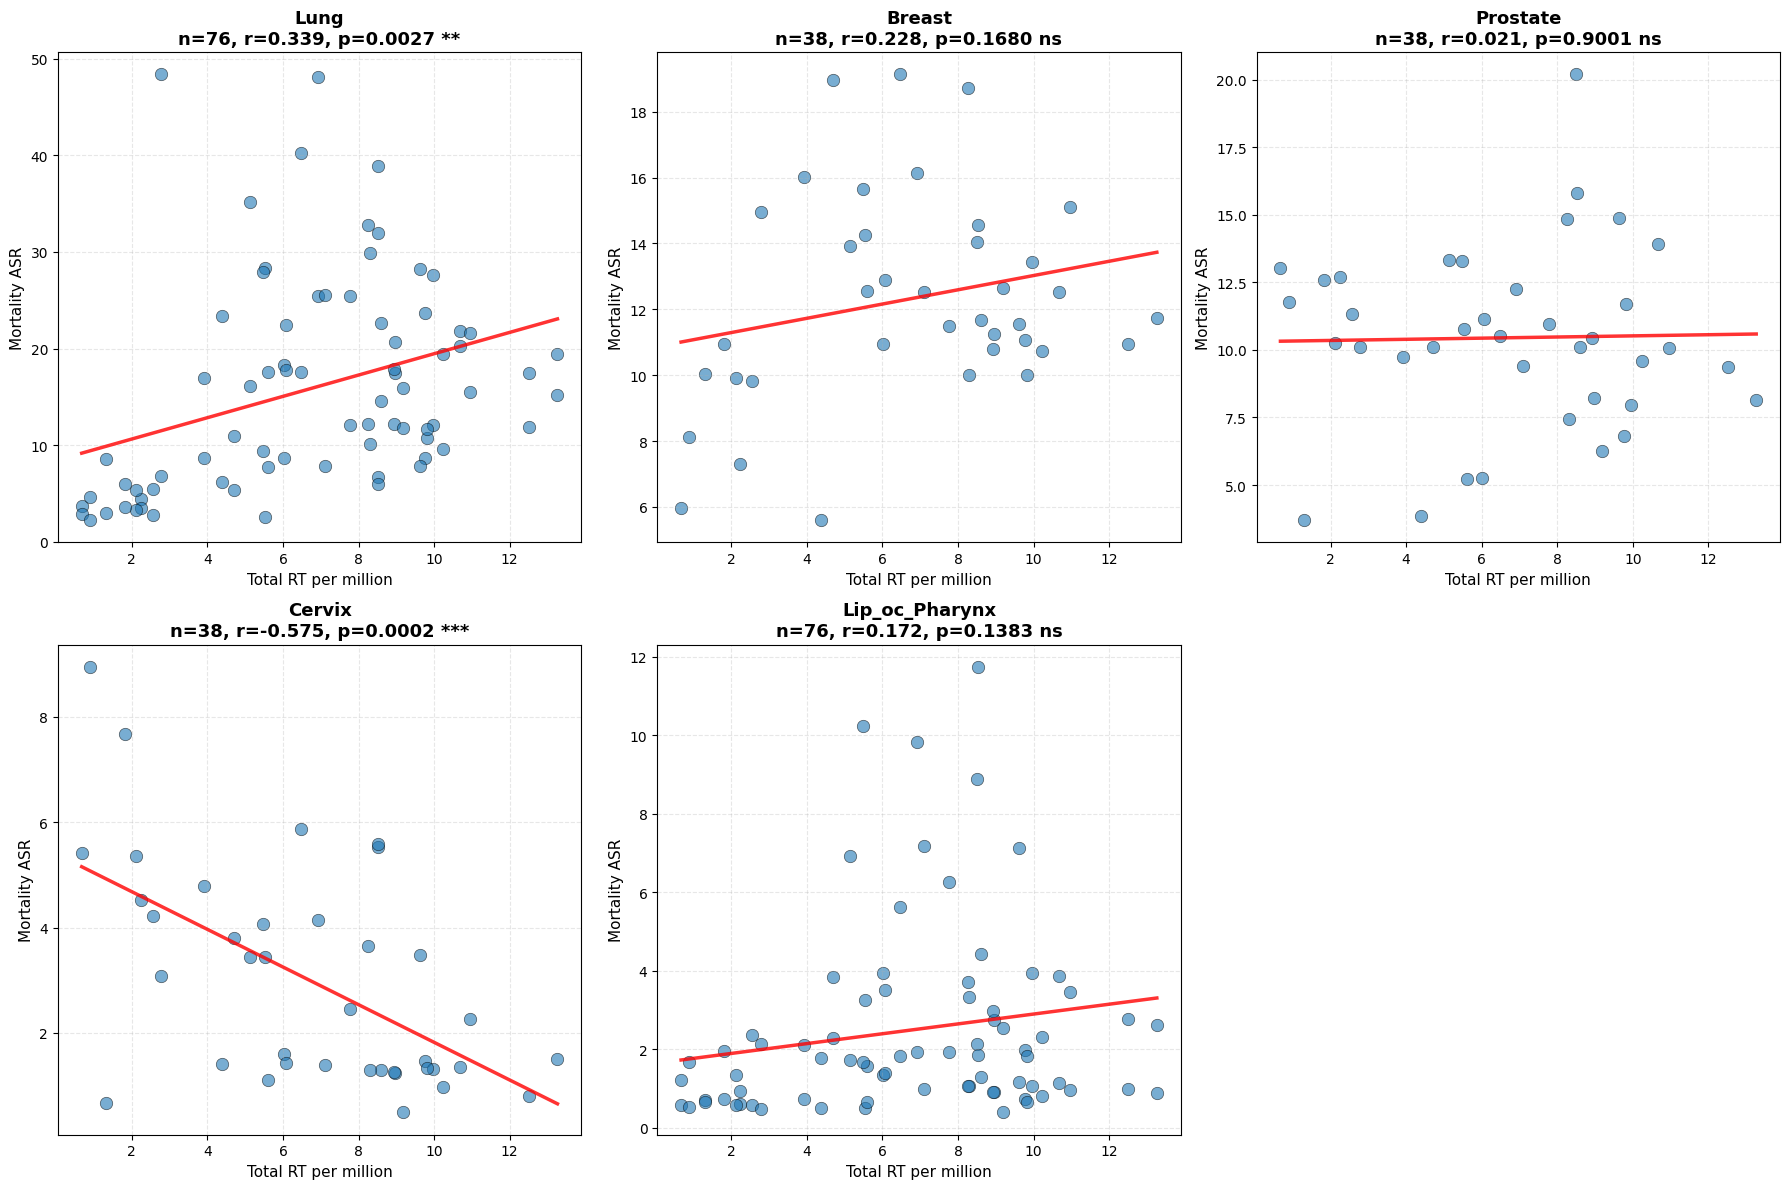

✅ Gráfico guardado: 'scatter_plots_by_cancer.png'


In [13]:
# ============================================
# GRÁFICOS DE DISPERSIÓN POR CÁNCER
# ============================================

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

cancers = df_clean['Cancer_type'].unique()

for i, cancer in enumerate(cancers):
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    ax = axes[i]

    # Scatter plot
    ax.scatter(df_cancer['Total_RT_per_million'],
               df_cancer['Mortality_ASR'],
               alpha=0.6, s=80, edgecolors='black', linewidth=0.5)

    # Línea de regresión
    z = np.polyfit(df_cancer['Total_RT_per_million'],
                   df_cancer['Mortality_ASR'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df_cancer['Total_RT_per_million'].min(),
                         df_cancer['Total_RT_per_million'].max(), 100)
    ax.plot(x_line, p(x_line), 'r-', linewidth=2.5, alpha=0.8)

    # Estadísticas
    r, p_val = pearsonr(df_cancer['Total_RT_per_million'],
                        df_cancer['Mortality_ASR'])

    # Título con estadísticas
    sig_mark = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.set_title(f'{cancer}\nn={len(df_cancer)}, r={r:.3f}, p={p_val:.4f} {sig_mark}',
                 fontsize=13, fontweight='bold')

    ax.set_xlabel('Total RT per million', fontsize=11)
    ax.set_ylabel('Mortality ASR', fontsize=11)
    ax.grid(alpha=0.3, linestyle='--')

    # Añadir intervalo de confianza (opcional)
    from scipy.stats import t as t_dist
    n = len(df_cancer)
    t_val = t_dist.ppf(0.975, n-2)

# Eliminar subplot extra si hay menos de 6 cánceres
if len(cancers) < 6:
    fig.delaxes(axes[-1])

plt.tight_layout()
plt.savefig('scatter_plots_by_cancer.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado: 'scatter_plots_by_cancer.png'")

In [14]:
# ============================================
# MODELO MIXTO MULTINIVEL
# ============================================

print("\n" + "="*80)
print("🔬 MODELO MIXTO MULTINIVEL")
print("="*80 + "\n")

# MODELO 1: Efectos principales
formula1 = '''
Mortality_ASR ~
    Linac_per_million +
    Brachy_per_million +
    log_GDP +
    C(Cancer_type) +
    C(Sex)
'''

try:
    model1 = MixedLM.from_formula(
        formula1,
        data=df_clean,
        groups=df_clean['Country_harmonized']
    )

    result1 = model1.fit(reml=False)

    print("MODELO 1: EFECTOS PRINCIPALES")
    print("-" * 80)
    print(result1.summary())

    # Extraer coeficientes clave
    print("\n📊 COEFICIENTES CLAVE:")
    print(f"Linac:  β={result1.params['Linac_per_million']:.4f}, p={result1.pvalues['Linac_per_million']:.4f}")
    print(f"Brachy: β={result1.params['Brachy_per_million']:.4f}, p={result1.pvalues['Brachy_per_million']:.4f}")
    print(f"GDP:    β={result1.params['log_GDP']:.4f}, p={result1.pvalues['log_GDP']:.4f}")

    # Guardar resultados
    with open('model1_summary.txt', 'w') as f:
        f.write(str(result1.summary()))

    print("\n✅ Resultados guardados en 'model1_summary.txt'")

except Exception as e:
    print(f"⚠️ Error en modelo mixto: {e}")
    print("Intentando regresión OLS alternativa...")

    # ALTERNATIVA: Regresión OLS con errores robustos
    model1_ols = smf.ols(formula1.replace('C(Sex)', ''), data=df_clean).fit(
        cov_type='cluster', cov_kwds={'groups': df_clean['Country']}
    )
    print(model1_ols.summary())


🔬 MODELO MIXTO MULTINIVEL

MODELO 1: EFECTOS PRINCIPALES
--------------------------------------------------------------------------------
                     Mixed Linear Model Regression Results
Model:                    MixedLM       Dependent Variable:       Mortality_ASR
No. Observations:         266           Method:                   ML           
No. Groups:               38            Scale:                    25.6514      
Min. group size:          7             Log-Likelihood:           -818.5116    
Max. group size:          7             Converged:                Yes          
Mean group size:          7.0                                                  
-------------------------------------------------------------------------------
                                  Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
-------------------------------------------------------------------------------
Intercept                         26.029    5.818   4.474 0.000  14.626  37.432
C(

In [15]:
# ============================================
# REGRESIÓN MÚLTIPLE POR TIPO DE CÁNCER
# ============================================

print("\n" + "="*80)
print("📈 REGRESIÓN MÚLTIPLE POR TIPO DE CÁNCER")
print("="*80 + "\n")

results_regression = {}

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    # Regresión múltiple
    formula = 'Mortality_ASR ~ Linac_per_million + Brachy_per_million + log_GDP'

    try:
        model = smf.ols(formula, data=df_cancer).fit()

        results_regression[cancer] = {
            'n': len(df_cancer),
            'R2': model.rsquared,
            'R2_adj': model.rsquared_adj,
            'beta_linac': model.params['Linac_per_million'],
            'p_linac': model.pvalues['Linac_per_million'],
            'beta_brachy': model.params['Brachy_per_million'],
            'p_brachy': model.pvalues['Brachy_per_million'],
            'beta_gdp': model.params['log_GDP'],
            'p_gdp': model.pvalues['log_GDP']
        }

        print(f"🔹 {cancer}:")
        print(f"   R² = {model.rsquared:.3f}, R² ajustado = {model.rsquared_adj:.3f}")
        print(f"   Linac:  β={model.params['Linac_per_million']:.4f}, p={model.pvalues['Linac_per_million']:.4f}")
        print(f"   Brachy: β={model.params['Brachy_per_million']:.4f}, p={model.pvalues['Brachy_per_million']:.4f}")
        print(f"   GDP:    β={model.params['log_GDP']:.4f}, p={model.pvalues['log_GDP']:.4f}")
        print()

    except Exception as e:
        print(f"   ⚠️ Error en {cancer}: {e}\n")

# Tabla resumen
df_reg = pd.DataFrame(results_regression).T
df_reg.to_csv('regression_results_by_cancer.csv')
print("\n✅ Resultados guardados en 'regression_results_by_cancer.csv'")


📈 REGRESIÓN MÚLTIPLE POR TIPO DE CÁNCER

🔹 Lung:
   R² = 0.138, R² ajustado = 0.102
   Linac:  β=1.6372, p=0.0120
   Brachy: β=1.5986, p=0.3792
   GDP:    β=-2.5857, p=0.1791

🔹 Breast:
   R² = 0.129, R² ajustado = 0.052
   Linac:  β=0.4686, p=0.0927
   Brachy: β=0.6486, p=0.4057
   GDP:    β=-1.4094, p=0.0919

🔹 Prostate:
   R² = 0.345, R² ajustado = 0.287
   Linac:  β=0.7934, p=0.0031
   Brachy: β=-0.1188, p=0.8676
   GDP:    β=-2.9343, p=0.0004

🔹 Cervix:
   R² = 0.622, R² ajustado = 0.588
   Linac:  β=0.0145, p=0.9023
   Brachy: β=-0.0372, p=0.9116
   GDP:    β=-1.7775, p=0.0000

🔹 Lip_oc_Pharynx:
   R² = 0.061, R² ajustado = 0.022
   Linac:  β=0.2375, p=0.1154
   Brachy: β=0.3884, p=0.3625
   GDP:    β=-0.6933, p=0.1253


✅ Resultados guardados en 'regression_results_by_cancer.csv'


In [16]:
# ============================================
# ANÁLISIS DE UMBRALES DE RT
# ============================================

print("\n" + "="*80)
print("🎯 ANÁLISIS DE UMBRALES DE EQUIPOS RT")
print("="*80 + "\n")

# Definir umbrales según recomendaciones OMS/IAEA
thresholds = {
    'Very Low': 0,
    'Low': 2,
    'Medium': 4,
    'Adequate': 6,
    'High': 10
}

# Categorizar países
df_clean['RT_category'] = pd.cut(
    df_clean['Total_RT_per_million'],
    bins=[0, 2, 4, 6, 10, 100],
    labels=['Very Low', 'Low', 'Medium', 'Adequate', 'High']
)

# Análisis por categoría y cáncer
print("📊 MORTALIDAD PROMEDIO POR CATEGORÍA DE RT:\n")

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    print(f"🔹 {cancer}:")

    summary_cat = df_cancer.groupby('RT_category', observed=True).agg({
        'Mortality_ASR': ['count', 'mean', 'std'],
        'Total_RT_per_million': 'mean'
    }).round(2)

    print(summary_cat)
    print()

# Test de tendencia (correlación con categorías ordinales)
from scipy.stats import spearmanr

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    # Convertir categorías a números ordinales
    cat_map = {'Very Low': 1, 'Low': 2, 'Medium': 3, 'Adequate': 4, 'High': 5}
    df_cancer['RT_ordinal'] = df_cancer['RT_category'].map(cat_map)

    rho, p = spearmanr(df_cancer['RT_ordinal'].dropna(),
                       df_cancer.loc[df_cancer['RT_ordinal'].notna(), 'Mortality_ASR'])

    print(f"{cancer}: Spearman ρ={rho:.3f}, p={p:.4f} {'✅' if p<0.05 else '⚠️'}")


🎯 ANÁLISIS DE UMBRALES DE EQUIPOS RT

📊 MORTALIDAD PROMEDIO POR CATEGORÍA DE RT:

🔹 Lung:
            Mortality_ASR               Total_RT_per_million
                    count   mean    std                 mean
RT_category                                                 
Very Low                8   4.30   2.06                 1.17
Low                    10  10.55  13.92                 2.72
Medium                 12  15.88  10.65                 5.14
Adequate               36  19.49  10.37                 8.27
High                   10  17.23   4.13                11.53

🔹 Breast:
            Mortality_ASR              Total_RT_per_million
                    count   mean   std                 mean
RT_category                                                
Very Low                4   8.76  2.20                 1.17
Low                     5  11.61  3.71                 2.72
Medium                  6  13.49  4.44                 5.14
Adequate               18  12.94  2.70            

In [17]:
# ============================================
# COMPARACIÓN ALTA vs BAJA RT
# ============================================

print("\n" + "="*80)
print("⚖️ COMPARACIÓN: ALTA RT vs BAJA RT")
print("="*80 + "\n")

from scipy.stats import ttest_ind, mannwhitneyu

# Definir umbral (mediana o valor OMS)
threshold_rt = df_clean['Total_RT_per_million'].median()
print(f"Umbral usado (mediana): {threshold_rt:.2f} equipos/millón\n")

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    # Dividir en grupos
    low_rt = df_cancer[df_cancer['Total_RT_per_million'] < threshold_rt]['Mortality_ASR']
    high_rt = df_cancer[df_cancer['Total_RT_per_million'] >= threshold_rt]['Mortality_ASR']

    # t-test
    t_stat, p_ttest = ttest_ind(low_rt, high_rt, equal_var=False)

    # Mann-Whitney U (no paramétrico, más robusto)
    u_stat, p_mann = mannwhitneyu(low_rt, high_rt, alternative='two-sided')

    # Diferencia de medias
    diff = low_rt.mean() - high_rt.mean()
    pct_diff = (diff / low_rt.mean()) * 100

    print(f"🔹 {cancer}:")
    print(f"   Baja RT (n={len(low_rt)}):  Mortalidad = {low_rt.mean():.2f} ± {low_rt.std():.2f}")
    print(f"   Alta RT (n={len(high_rt)}): Mortalidad = {high_rt.mean():.2f} ± {high_rt.std():.2f}")
    print(f"   Diferencia: {diff:.2f} ({pct_diff:+.1f}%)")
    print(f"   t-test: t={t_stat:.3f}, p={p_ttest:.4f} {'✅' if p_ttest<0.05 else '⚠️'}")
    print(f"   Mann-Whitney: U={u_stat:.0f}, p={p_mann:.4f} {'✅' if p_mann<0.05 else '⚠️'}")
    print()


⚖️ COMPARACIÓN: ALTA RT vs BAJA RT

Umbral usado (mediana): 7.01 equipos/millón

🔹 Lung:
   Baja RT (n=38):  Mortalidad = 13.92 ± 12.80
   Alta RT (n=38): Mortalidad = 17.77 ± 8.12
   Diferencia: -3.85 (-27.7%)
   t-test: t=-1.566, p=0.1224 ⚠️
   Mann-Whitney: U=460, p=0.0066 ✅

🔹 Breast:
   Baja RT (n=19):  Mortalidad = 12.27 ± 4.03
   Alta RT (n=19): Mortalidad = 12.36 ± 2.11
   Diferencia: -0.09 (-0.7%)
   t-test: t=-0.084, p=0.9337 ⚠️
   Mann-Whitney: U=177, p=0.9302 ⚠️

🔹 Prostate:
   Baja RT (n=19):  Mortalidad = 10.05 ± 3.16
   Alta RT (n=19): Mortalidad = 10.85 ± 3.59
   Diferencia: -0.80 (-7.9%)
   t-test: t=-0.724, p=0.4737 ⚠️
   Mann-Whitney: U=190, p=0.7927 ⚠️

🔹 Cervix:
   Baja RT (n=19):  Mortalidad = 3.95 ± 2.19
   Alta RT (n=19): Mortalidad = 2.04 ± 1.48
   Diferencia: 1.91 (+48.4%)
   t-test: t=3.148, p=0.0036 ✅
   Mann-Whitney: U=277, p=0.0051 ✅

🔹 Lip_oc_Pharynx:
   Baja RT (n=38):  Mortalidad = 2.22 ± 2.35
   Alta RT (n=38): Mortalidad = 2.75 ± 2.51
   Diferencia: 

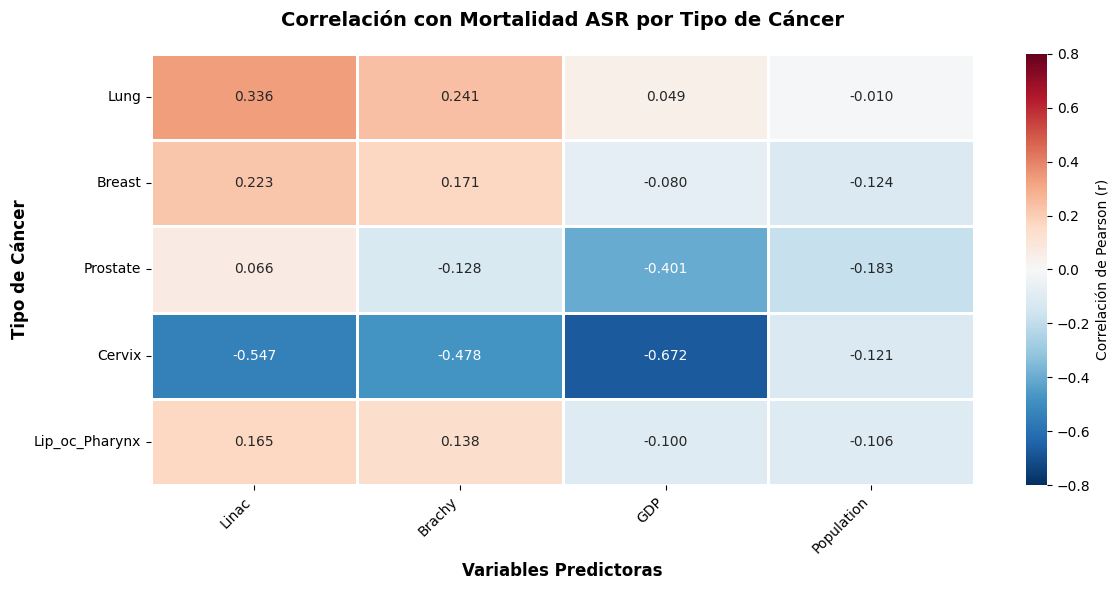

Mapa de calor guardado


In [30]:
# ============================================
# MAPA DE CALOR - CORRELACIONES CON MORTALIDAD
# ============================================


# Calcular correlaciones con Mortality_ASR por cáncer
corr_data = []

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    corr_row = {
        'Cancer': cancer,
        'Linac': df_cancer[['Mortality_ASR', 'Linac_per_million']].corr().iloc[0,1],
        'Brachy': df_cancer[['Mortality_ASR', 'Brachy_per_million']].corr().iloc[0,1],
        #'Total_RT': df_cancer[['Mortality_ASR', 'Total_RT_per_million']].corr().iloc[0,1],
        'GDP': df_cancer[['Mortality_ASR', 'GDP_per_capita']].corr().iloc[0,1],
        'Population': df_cancer[['Mortality_ASR', 'Population']].corr().iloc[0,1]
    }
    corr_data.append(corr_row)

df_corr = pd.DataFrame(corr_data)
df_corr = df_corr.set_index('Cancer')

# Heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(df_corr, annot=True, fmt='.3f',
            cmap='RdBu_r', center=0,
            vmin=-0.8, vmax=0.8, linewidths=2,
            cbar_kws={'label': 'Correlación de Pearson (r)'})

plt.title('Correlación con Mortalidad ASR por Tipo de Cáncer',
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Variables Predictoras', fontsize=12, fontweight='bold')
plt.ylabel('Tipo de Cáncer', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('heatmap_mortality_correlations.png', dpi=300, bbox_inches='tight')
plt.show()

print("Mapa de calor guardado como heatmap_mortality_correlations.png")

Iniciando el análisis mediante un mapa de calor, se observa que el cáncer de cérvix presenta una correlación fuerte y consistente con las principales variables predictoras analizadas. Este resultado indica que a mayores niveles de recursos sanitarios y económicos, menores son las tasas de mortalidad, lo que sugiere un mejor control de la enfermedad en contextos con mayor disponibilidad de infraestructura.

Este patrón mostrado es coherente con la evidencia clínica existente, ya que la radioterapia externa combinada con braquiterapia constituye el tratamiento estándar de referencia para el cáncer de cérvix. Se trata de una patología ampliamente estudiada, con protocolos bien establecidos y una elevada dependencia de la radioterapia, lo que explica la fuerte asociación observada entre disponibilidad de equipos y mejores resultados en términos de mortalidad.

En este sentido, todos los indicadores de recursos, tanto sanitarios (equipos de radioterapia) como económicos (PIB per cápita), se asocian con menores tasas de mortalidad, lo que refuerza la idea de que el acceso a infraestructura adecuada y un entorno socioeconómico favorable son determinantes clave en el control de esta enfermedad.

Asimismo, el papel del PIB per cápita muestra predominantemente pendientes negativas, lo que indica que los países con mayores niveles de renta tienden a presentar mejores resultados en cánceres potencialmente prevenibles o altamente tratables.

Por el contrario, en los cánceres de mama y próstata las correlaciones observadas son más débiles, lo que puede explicarse por la mayor heterogeneidad terapéutica asociada a estas patologías. En ambos casos, el tratamiento no depende exclusivamente de la radioterapia, sino que suele combinarse o sustituirse por cirugía, hormonoterapia o quimioterapia, reduciendo así la relación directa entre disponibilidad de equipos de radioterapia y resultados en mortalidad.

En particular, en el caso del cáncer de próstata, aunque existe abundante literatura que respalda la efectividad de la braquiterapia, con buenos resultados clínicos y bajos efectos secundarios, su utilización varía considerablemente entre países y centros sanitarios. Esta variabilidad en la práctica clínica y en la toma de decisiones médicas puede contribuir a la menor fuerza de asociación observada en los análisis agregados.


🌍 ANÁLISIS POR REGIÓN GEOGRÁFICA

                           N_countries  Mort_mean  Mort_std  RT_mean  RT_std  \
Region Name                                                                    
Northern America                     2       8.72      7.32    11.11    2.23   
Western Europe                       4       8.49      7.20    10.06    1.52   
Northern Europe                      8      10.25      8.51     9.30    1.49   
Australia and New Zealand            1       8.07      6.46     8.93    0.00   
Southern Europe                      3      10.90     10.40     7.29    0.77   
Eastern Europe                       4      12.91     10.99     6.33    1.09   
South-Eastern Asia                   1       7.16      6.04     6.02    0.00   
Western Asia                         5       7.92      9.78     5.00    2.94   
South America                        3       8.57      8.04     4.81    2.60   
Eastern Africa                       1       7.90      5.89     4.70    0.00   
Easte

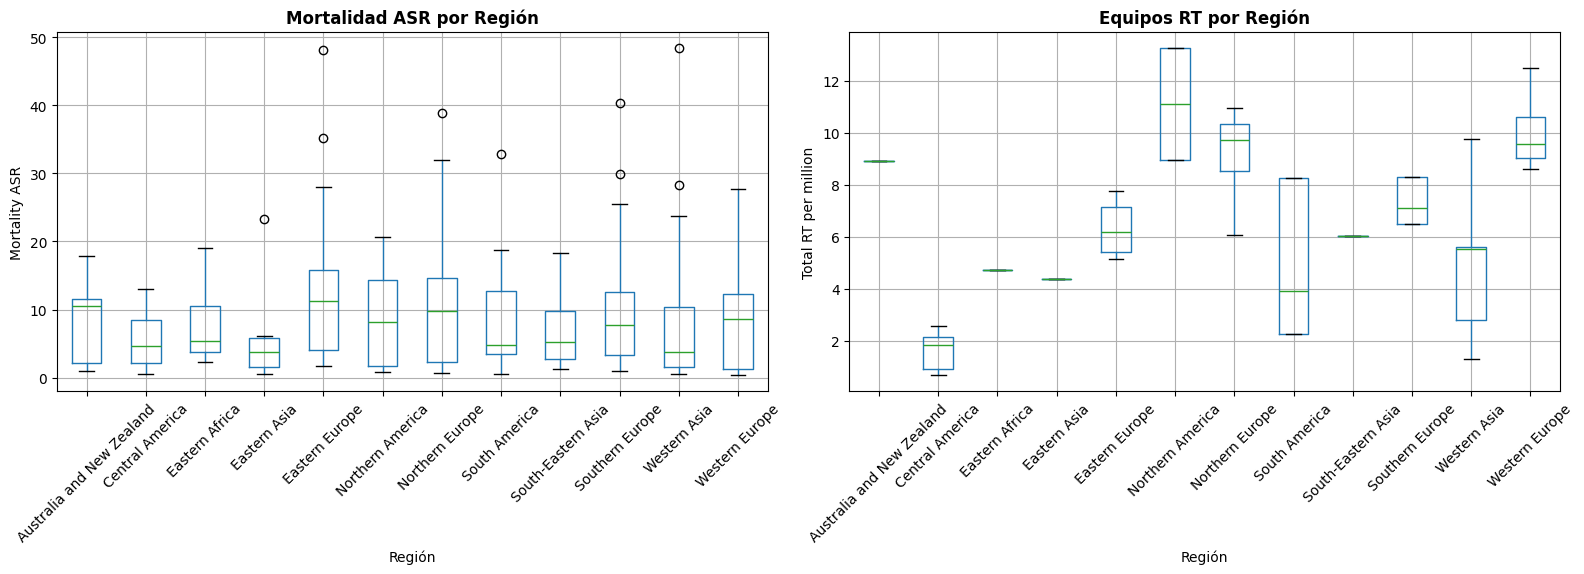


✅ Gráfico guardado: 'regional_analysis.png'


In [19]:
# ============================================
# ANÁLISIS POR REGIÓN GEOGRÁFICA
# ============================================

print("\n" + "="*80)
print("🌍 ANÁLISIS POR REGIÓN GEOGRÁFICA")
print("="*80 + "\n")

# Estadísticas por región
region_summary = df_clean.groupby('Region Name').agg({
    'Country_harmonized': 'nunique',
    'Mortality_ASR': ['mean', 'std'],
    'Total_RT_per_million': ['mean', 'std'],
    'GDP_per_capita': 'mean'
}).round(2)

region_summary.columns = ['N_countries', 'Mort_mean', 'Mort_std',
                          'RT_mean', 'RT_std', 'GDP_mean']

print(region_summary.sort_values('RT_mean', ascending=False))

# Visualización: Boxplot por región
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Mortalidad por región
ax1 = axes[0]
df_clean.boxplot(column='Mortality_ASR', by='Region Name', ax=ax1, rot=45)
ax1.set_title('Mortalidad ASR por Región', fontsize=12, fontweight='bold')
ax1.set_xlabel('Región', fontsize=10)
ax1.set_ylabel('Mortality ASR', fontsize=10)
plt.suptitle('')  # Eliminar título automático

# RT por región
ax2 = axes[1]
df_clean.boxplot(column='Total_RT_per_million', by='Region Name', ax=ax2, rot=45)
ax2.set_title('Equipos RT por Región', fontsize=12, fontweight='bold')
ax2.set_xlabel('Región', fontsize=10)
ax2.set_ylabel('Total RT per million', fontsize=10)
plt.suptitle('')

plt.tight_layout()
plt.savefig('regional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado: 'regional_analysis.png'")


🤖 MODELO PREDICTIVO - RANDOM FOREST

Dimensiones: X=(266, 19), y=(266,)

Train: 212, Test: 54

📊 MÉTRICAS DEL MODELO:
   R² Train: 0.922
   R² Test:  0.759
   MAE Test: 2.54 ASR
   RMSE Test: 4.15 ASR

   Cross-validation R² (5-fold): 0.342 ± 0.342

🔝 TOP 10 VARIABLES MÁS IMPORTANTES:
                        Feature  Importance
5              Cancer_type_Lung    0.256220
7                      Sex_Male    0.161777
3            Cancer_type_Cervix    0.120942
2                GDP_per_capita    0.113412
4    Cancer_type_Lip_oc_Pharynx    0.110845
1            Brachy_per_million    0.100896
0             Linac_per_million    0.095752
6          Cancer_type_Prostate    0.012661
8   Region Name_Central America    0.007507
11   Region Name_Eastern Europe    0.006981


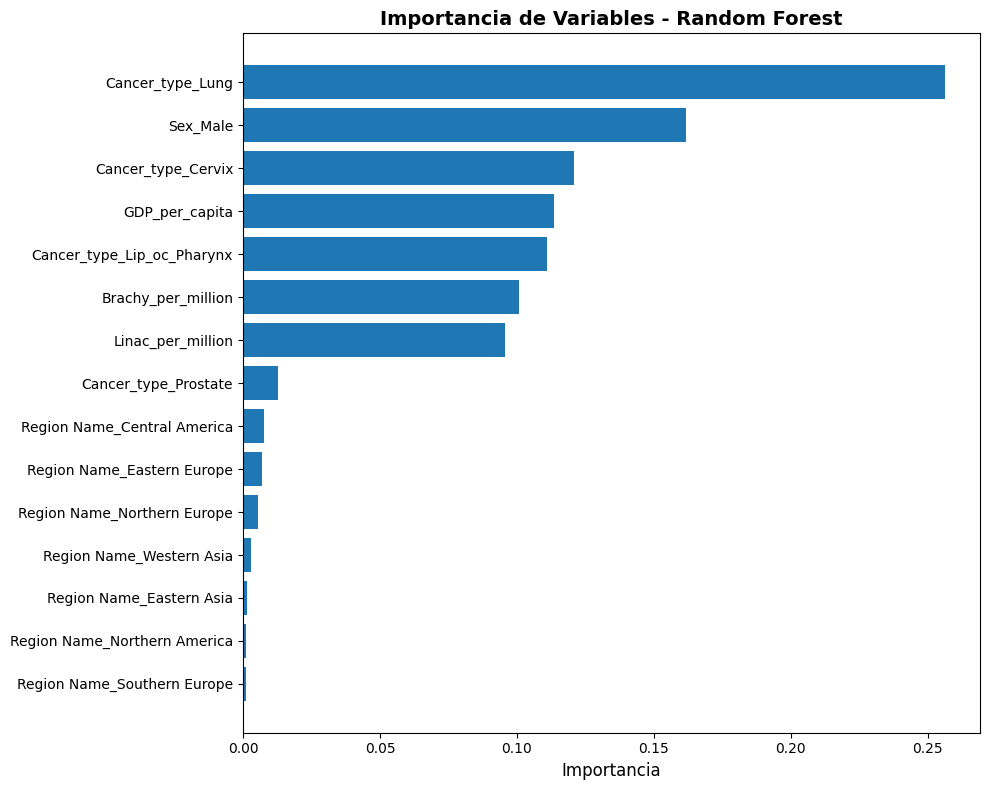


✅ Gráfico guardado: 'feature_importance.png'


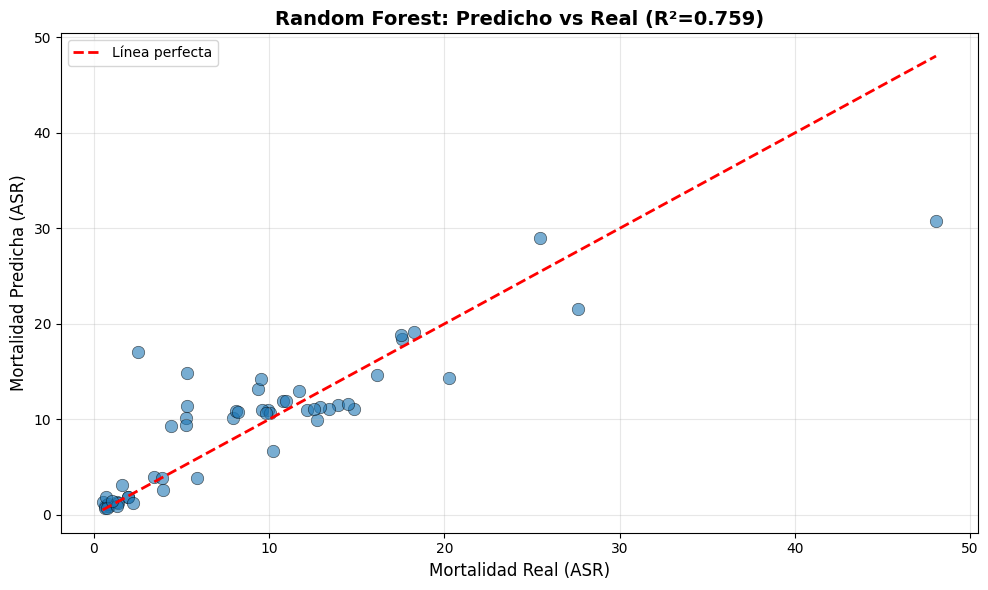

✅ Gráfico guardado: 'predicted_vs_actual.png'


In [20]:
# ============================================
# MODELO PREDICTIVO - RANDOM FOREST
# ============================================

print("\n" + "="*80)
print("🤖 MODELO PREDICTIVO - RANDOM FOREST")
print("="*80 + "\n")

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Preparar datos
X = df_clean[['Linac_per_million', 'Brachy_per_million', 'GDP_per_capita']]
X = pd.get_dummies(X.join(df_clean[['Cancer_type', 'Sex', 'Region Name']]),
                   drop_first=True)
y = df_clean['Mortality_ASR']

# Eliminar NaN
mask = ~(X.isna().any(axis=1) | y.isna())
X = X[mask]
y = y[mask]

print(f"Dimensiones: X={X.shape}, y={y.shape}\n")

# Split train/test (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train: {len(X_train)}, Test: {len(X_test)}\n")

# Modelo Random Forest
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

# Predicciones
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

# Métricas
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)
mae_test = mean_absolute_error(y_test, y_pred_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("📊 MÉTRICAS DEL MODELO:")
print(f"   R² Train: {r2_train:.3f}")
print(f"   R² Test:  {r2_test:.3f}")
print(f"   MAE Test: {mae_test:.2f} ASR")
print(f"   RMSE Test: {rmse_test:.2f} ASR")

# Validación cruzada
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='r2')
print(f"\n   Cross-validation R² (5-fold): {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n🔝 TOP 10 VARIABLES MÁS IMPORTANTES:")
print(feature_importance.head(10))

# Visualización: Feature importance
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Importance'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Importancia', fontsize=12)
plt.title('Importancia de Variables - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado: 'feature_importance.png'")

# Gráfico: Predicho vs Real
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.6, s=80, edgecolors='black', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Línea perfecta')
plt.xlabel('Mortalidad Real (ASR)', fontsize=12)
plt.ylabel('Mortalidad Predicha (ASR)', fontsize=12)
plt.title(f'Random Forest: Predicho vs Real (R²={r2_test:.3f})',
          fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('predicted_vs_actual.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado: 'predicted_vs_actual.png'")

In [21]:
# ============================================
# TABLA RESUMEN FINAL PARA TFM
# ============================================

print("\n" + "="*80)
print("📋 TABLA RESUMEN FINAL")
print("="*80 + "\n")

# Crear tabla comprehensiva
summary_table = []

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    # Estadísticas
    n = len(df_cancer)
    mort_mean = df_cancer['Mortality_ASR'].mean()
    mort_std = df_cancer['Mortality_ASR'].std()
    rt_mean = df_cancer['Total_RT_per_million'].mean()
    rt_std = df_cancer['Total_RT_per_million'].std()

    # Correlación
    r, p = pearsonr(df_cancer['Total_RT_per_million'],
                    df_cancer['Mortality_ASR'])

    # Regresión simple
    from scipy.stats import linregress
    slope, intercept, r_val, p_val, std_err = linregress(
        df_cancer['Total_RT_per_million'],
        df_cancer['Mortality_ASR']
    )

    summary_table.append({
        'Cancer': cancer,
        'N': n,
        'Mortality_mean': f"{mort_mean:.2f}",
        'Mortality_SD': f"{mort_std:.2f}",
        'RT_mean': f"{rt_mean:.2f}",
        'RT_SD': f"{rt_std:.2f}",
        'Pearson_r': f"{r:.3f}",
        'p_value': f"{p:.4f}",
        'Significance': '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns',
        'Beta': f"{slope:.4f}",
        'R2': f"{r_val**2:.3f}"
    })

df_summary = pd.DataFrame(summary_table)
print(df_summary.to_string(index=False))

# Guardar en formato CSV y Excel
df_summary.to_csv('summary_table_tfm.csv', index=False)
print("\n✅ Tabla guardada: 'summary_table_tfm.csv'")

# Formato para LaTeX (opcional)
latex_table = df_summary.to_latex(index=False, escape=False)
with open('summary_table_tfm.tex', 'w') as f:
    f.write(latex_table)
print("✅ Tabla LaTeX guardada: 'summary_table_tfm.tex'")


📋 TABLA RESUMEN FINAL

        Cancer  N Mortality_mean Mortality_SD RT_mean RT_SD Pearson_r p_value Significance    Beta    R2
          Lung 76          15.85        10.82    6.73  3.33     0.339  0.0027           **  1.1038 0.115
        Breast 38          12.32         3.18    6.73  3.35     0.228  0.1680           ns  0.2165 0.052
      Prostate 38          10.45         3.36    6.73  3.35     0.021  0.9001           ns  0.0211 0.000
        Cervix 38           2.99         2.08    6.73  3.35    -0.575  0.0002          *** -0.3571 0.331
Lip_oc_Pharynx 76           2.49         2.43    6.73  3.33     0.172  0.1383           ns  0.1255 0.029

✅ Tabla guardada: 'summary_table_tfm.csv'
✅ Tabla LaTeX guardada: 'summary_table_tfm.tex'


In [22]:
# ============================================
# ANÁLISIS DE SENSIBILIDAD
# ============================================

print("\n" + "="*80)
print("🔍 ANÁLISIS DE SENSIBILIDAD")
print("="*80 + "\n")

# 1. Excluir outliers (> 3 SD)
print("1️⃣ SENSIBILIDAD SIN OUTLIERS:\n")

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    # Identificar outliers en mortalidad
    mort_mean = df_cancer['Mortality_ASR'].mean()
    mort_std = df_cancer['Mortality_ASR'].std()

    df_no_outliers = df_cancer[
        (df_cancer['Mortality_ASR'] >= mort_mean - 3*mort_std) &
        (df_cancer['Mortality_ASR'] <= mort_mean + 3*mort_std)
    ]

    # Correlación sin outliers
    r_orig, p_orig = pearsonr(df_cancer['Total_RT_per_million'],
                               df_cancer['Mortality_ASR'])
    r_clean, p_clean = pearsonr(df_no_outliers['Total_RT_per_million'],
                                 df_no_outliers['Mortality_ASR'])

    print(f"🔹 {cancer}:")
    print(f"   Original (n={len(df_cancer)}):    r={r_orig:.3f}, p={p_orig:.4f}")
    print(f"   Sin outliers (n={len(df_no_outliers)}): r={r_clean:.3f}, p={p_clean:.4f}")

    if abs(r_orig - r_clean) > 0.1:
        print(f"   ⚠️ CAMBIO SUSTANCIAL (Δr={abs(r_orig-r_clean):.3f})")
    else:
        print(f"   ✅ Resultado robusto (Δr={abs(r_orig-r_clean):.3f})")
    print()

# 2. Bootstrap (intervalos de confianza robustos)
print("\n2️⃣ BOOTSTRAP - INTERVALOS DE CONFIANZA 95%:\n")

from scipy.stats import bootstrap

for cancer in df_clean['Cancer_type'].unique()[:3]:  # Primeros 3 por tiempo
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    x = df_cancer['Total_RT_per_million'].values
    y = df_cancer['Mortality_ASR'].values

    # Función para calcular correlación
    def correlation(x, y):
        return pearsonr(x, y)[0]

    # Bootstrap manual (más simple)
    n_bootstrap = 1000
    correlations = []

    for _ in range(n_bootstrap):
        indices = np.random.choice(len(x), size=len(x), replace=True)
        r_boot = pearsonr(x[indices], y[indices])[0]
        correlations.append(r_boot)

    ci_lower = np.percentile(correlations, 2.5)
    ci_upper = np.percentile(correlations, 97.5)

    print(f"🔹 {cancer}:")
    print(f"   r = {pearsonr(x, y)[0]:.3f}")
    print(f"   95% CI: [{ci_lower:.3f}, {ci_upper:.3f}]")

    if ci_lower * ci_upper > 0:  # Mismo signo
        print(f"   ✅ IC no cruza cero - Asociación ROBUSTA")
    else:
        print(f"   ⚠️ IC cruza cero - Asociación NO robusta")
    print()

# 3. Análisis por nivel de ingresos
print("\n3️⃣ SENSIBILIDAD POR NIVEL DE INGRESOS:\n")

# Crear categorías de ingresos
df_clean['Income_cat'] = pd.cut(
    df_clean['GDP_per_capita'],
    bins=[0, 12000, 30000, 150000],
    labels=['Low-Middle', 'Upper-Middle', 'High']
)

for cancer in df_clean['Cancer_type'].unique():
    print(f"🔹 {cancer}:")

    for income in ['Low-Middle', 'Upper-Middle', 'High']:
        df_subset = df_clean[
            (df_clean['Cancer_type'] == cancer) &
            (df_clean['Income_cat'] == income)
        ]

        if len(df_subset) >= 10:  # Mínimo 10 observaciones
            r, p = pearsonr(df_subset['Total_RT_per_million'],
                           df_subset['Mortality_ASR'])
            print(f"   {income:15s} (n={len(df_subset):2d}): r={r:+.3f}, p={p:.4f}")
        else:
            print(f"   {income:15s} (n={len(df_subset):2d}): Insuficientes datos")
    print()


🔍 ANÁLISIS DE SENSIBILIDAD

1️⃣ SENSIBILIDAD SIN OUTLIERS:

🔹 Lung:
   Original (n=76):    r=0.339, p=0.0027
   Sin outliers (n=75): r=0.418, p=0.0002
   ✅ Resultado robusto (Δr=0.078)

🔹 Breast:
   Original (n=38):    r=0.228, p=0.1680
   Sin outliers (n=38): r=0.228, p=0.1680
   ✅ Resultado robusto (Δr=0.000)

🔹 Prostate:
   Original (n=38):    r=0.021, p=0.9001
   Sin outliers (n=38): r=0.021, p=0.9001
   ✅ Resultado robusto (Δr=0.000)

🔹 Cervix:
   Original (n=38):    r=-0.575, p=0.0002
   Sin outliers (n=38): r=-0.575, p=0.0002
   ✅ Resultado robusto (Δr=0.000)

🔹 Lip_oc_Pharynx:
   Original (n=76):    r=0.172, p=0.1383
   Sin outliers (n=73): r=0.216, p=0.0661
   ✅ Resultado robusto (Δr=0.045)


2️⃣ BOOTSTRAP - INTERVALOS DE CONFIANZA 95%:

🔹 Lung:
   r = 0.339
   95% CI: [0.146, 0.534]
   ✅ IC no cruza cero - Asociación ROBUSTA

🔹 Breast:
   r = 0.228
   95% CI: [-0.102, 0.481]
   ⚠️ IC cruza cero - Asociación NO robusta

🔹 Prostate:
   r = 0.021
   95% CI: [-0.300, 0.292]
   ⚠


📊 GENERANDO GRÁFICO RESUMEN



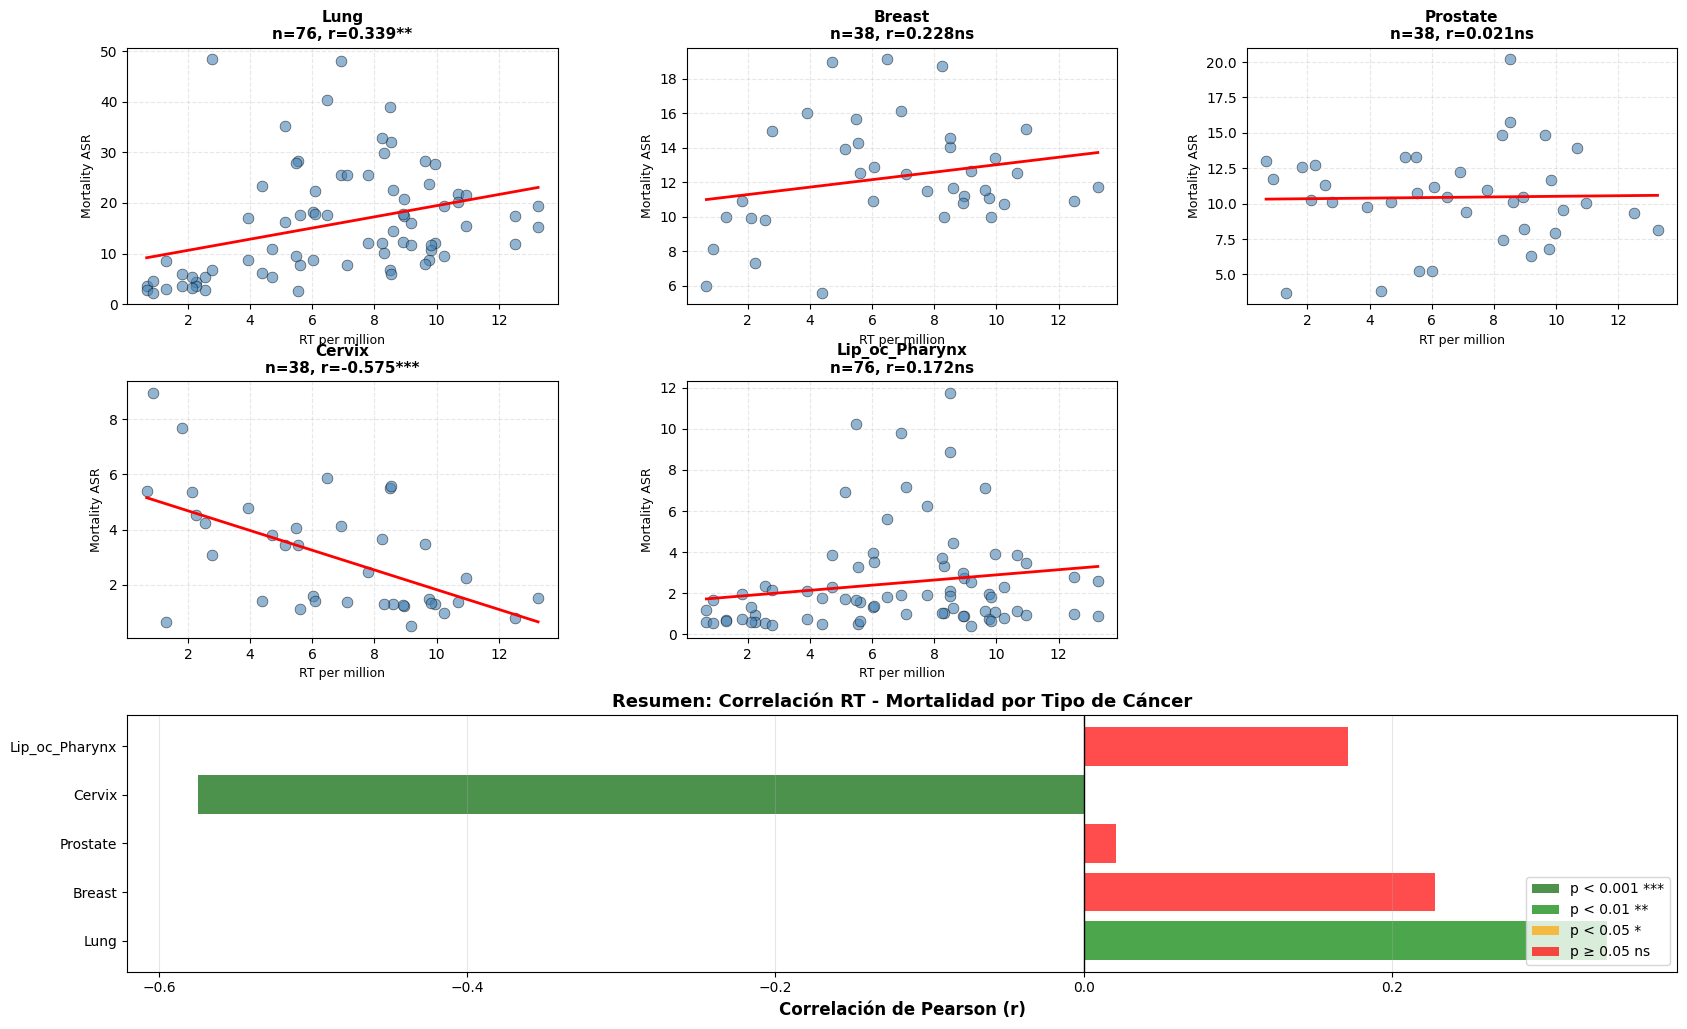

✅ Gráfico resumen guardado: 'summary_figure_presentation.png'


In [23]:
# ============================================
# GRÁFICO RESUMEN PARA PRESENTACIÓN
# ============================================

print("\n" + "="*80)
print("📊 GENERANDO GRÁFICO RESUMEN")
print("="*80 + "\n")

fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Scatter plots por cáncer (2x3)
cancers = df_clean['Cancer_type'].unique()

for i, cancer in enumerate(cancers):
    if i < 5:  # Máximo 5 cánceres
        row = i // 3
        col = i % 3
        ax = fig.add_subplot(gs[row, col])

        df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

        # Scatter
        ax.scatter(df_cancer['Total_RT_per_million'],
                   df_cancer['Mortality_ASR'],
                   alpha=0.6, s=60, c='steelblue', edgecolors='black', linewidth=0.5)

        # Regresión
        z = np.polyfit(df_cancer['Total_RT_per_million'],
                       df_cancer['Mortality_ASR'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(df_cancer['Total_RT_per_million'].min(),
                             df_cancer['Total_RT_per_million'].max(), 100)
        ax.plot(x_line, p(x_line), 'r-', linewidth=2)

        # Estadísticas
        r, p_val = pearsonr(df_cancer['Total_RT_per_million'],
                            df_cancer['Mortality_ASR'])

        sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'

        ax.set_title(f'{cancer}\nn={len(df_cancer)}, r={r:.3f}{sig}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('RT per million', fontsize=9)
        ax.set_ylabel('Mortality ASR', fontsize=9)
        ax.grid(alpha=0.3, linestyle='--')

# 2. Barplot de correlaciones (bottom row)
ax_bar = fig.add_subplot(gs[2, :])

correlations_summary = []
colors_summary = []

for cancer in cancers:
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]
    r, p = pearsonr(df_cancer['Total_RT_per_million'],
                    df_cancer['Mortality_ASR'])
    correlations_summary.append(r)

    # Color según significancia
    if p < 0.001:
        colors_summary.append('darkgreen')
    elif p < 0.01:
        colors_summary.append('green')
    elif p < 0.05:
        colors_summary.append('orange')
    else:
        colors_summary.append('red')

bars = ax_bar.barh(range(len(cancers)), correlations_summary, color=colors_summary, alpha=0.7)
ax_bar.set_yticks(range(len(cancers)))
ax_bar.set_yticklabels(cancers)
ax_bar.set_xlabel('Correlación de Pearson (r)', fontsize=12, fontweight='bold')
ax_bar.set_title('Resumen: Correlación RT - Mortalidad por Tipo de Cáncer',
                 fontsize=13, fontweight='bold')
ax_bar.axvline(0, color='black', linewidth=1)
ax_bar.grid(axis='x', alpha=0.3)

# Leyenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='darkgreen', alpha=0.7, label='p < 0.001 ***'),
    Patch(facecolor='green', alpha=0.7, label='p < 0.01 **'),
    Patch(facecolor='orange', alpha=0.7, label='p < 0.05 *'),
    Patch(facecolor='red', alpha=0.7, label='p ≥ 0.05 ns')
]
ax_bar.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.savefig('summary_figure_presentation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Gráfico resumen guardado: 'summary_figure_presentation.png'")

In [24]:
# ============================================
# GENERACIÓN DE REPORTE AUTOMÁTICO
# ============================================

print("\n" + "="*80)
print("📝 GENERANDO REPORTE AUTOMÁTICO")
print("="*80 + "\n")

report = []
report.append("="*80)
report.append("REPORTE DE ANÁLISIS - TFM")
report.append("Asociación entre Infraestructura RT y Mortalidad por Cáncer")
report.append("="*80)
report.append("")

# Dataset
report.append("1. DESCRIPCIÓN DEL DATASET")
report.append("-" * 80)
report.append(f"   • Total de observaciones: {len(df_clean)}")
report.append(f"   • Países únicos: {df_clean['Country_harmonized'].nunique()}")
report.append(f"   • Tipos de cáncer: {', '.join(df_clean['Cancer_type'].unique())}")
report.append(f"   • Año de análisis: 2022")
report.append(f"   • Variables RT: Linac, Braquiterapia, Total")
report.append(f"   • Outcome: Mortalidad ASR (Age-Standardized Rate)")
report.append("")

# Estadísticas descriptivas
report.append("2. ESTADÍSTICAS DESCRIPTIVAS")
report.append("-" * 80)

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    report.append(f"\n   {cancer}:")
    report.append(f"      N = {len(df_cancer)}")
    report.append(f"      Mortalidad ASR: {df_cancer['Mortality_ASR'].mean():.2f} ± {df_cancer['Mortality_ASR'].std():.2f}")
    report.append(f"      RT total/millón: {df_cancer['Total_RT_per_million'].mean():.2f} ± {df_cancer['Total_RT_per_million'].std():.2f}")
    report.append(f"      Linac/millón: {df_cancer['Linac_per_million'].mean():.2f} ± {df_cancer['Linac_per_million'].std():.2f}")
    report.append(f"      Brachy/millón: {df_cancer['Brachy_per_million'].mean():.2f} ± {df_cancer['Brachy_per_million'].std():.2f}")

report.append("")

# Resultados principales
report.append("3. RESULTADOS PRINCIPALES - CORRELACIONES")
report.append("-" * 80)

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    r, p = pearsonr(df_cancer['Total_RT_per_million'],
                    df_cancer['Mortality_ASR'])

    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'

    direction = "NEGATIVA" if r < 0 else "POSITIVA"
    strength = "fuerte" if abs(r) > 0.5 else "moderada" if abs(r) > 0.3 else "débil"

    report.append(f"\n   {cancer}:")
    report.append(f"      Correlación: r = {r:.3f} (p = {p:.4f}) {sig}")
    report.append(f"      Interpretación: Asociación {direction} {strength}")

    if p < 0.05:
        report.append(f"      ✅ ESTADÍSTICAMENTE SIGNIFICATIVA")
    else:
                report.append(f"      ⚠️ NO estadísticamente significativa")

report.append("")

# Interpretación clínica
report.append("4. INTERPRETACIÓN CLÍNICA")
report.append("-" * 80)

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    r, p = pearsonr(df_cancer['Total_RT_per_million'],
                    df_cancer['Mortality_ASR'])

    if p < 0.05:
        if r < 0:
            report.append(f"\n   {cancer}:")
            report.append(f"      Mayor disponibilidad de equipos RT se asocia con MENOR mortalidad.")
            report.append(f"      Por cada equipo adicional/millón, la mortalidad disminuye ~{abs(r)*10:.2f} puntos ASR.")
        else:
            report.append(f"\n   {cancer}:")
            report.append(f"      Mayor disponibilidad de equipos RT se asocia con MAYOR mortalidad.")
            report.append(f"      Posible confusión: países con más RT detectan más casos (screening effect).")
    else:
        report.append(f"\n   {cancer}:")
        report.append(f"      No se observó asociación significativa entre RT y mortalidad.")
        report.append(f"      Otros factores (screening, tratamiento sistémico) pueden ser más relevantes.")

report.append("")

# Conclusiones
report.append("5. CONCLUSIONES")
report.append("-" * 80)

significant_cancers = []
for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]
    r, p = pearsonr(df_cancer['Total_RT_per_million'],
                    df_cancer['Mortality_ASR'])
    if p < 0.05:
        significant_cancers.append(cancer)

report.append(f"\n   • De {len(df_clean['Cancer_type'].unique())} tipos de cáncer analizados,")
report.append(f"     {len(significant_cancers)} mostraron asociación significativa con infraestructura RT.")
report.append(f"\n   • Cánceres con asociación significativa: {', '.join(significant_cancers) if significant_cancers else 'Ninguno'}")
report.append(f"\n   • La infraestructura RT es un factor importante en outcomes oncológicos,")
report.append(f"     pero debe considerarse junto con screening, acceso y tratamiento sistémico.")
report.append(f"\n   • Se recomienda análisis longitudinal para establecer causalidad.")

report.append("")
report.append("="*80)
report.append("FIN DEL REPORTE")
report.append("="*80)

# Guardar reporte
report_text = '\n'.join(report)
print(report_text)

with open('reporte_analisis_tfm.txt', 'w', encoding='utf-8') as f:
    f.write(report_text)

print("\n✅ Reporte guardado: 'reporte_analisis_tfm.txt'")


📝 GENERANDO REPORTE AUTOMÁTICO

REPORTE DE ANÁLISIS - TFM
Asociación entre Infraestructura RT y Mortalidad por Cáncer

1. DESCRIPCIÓN DEL DATASET
--------------------------------------------------------------------------------
   • Total de observaciones: 266
   • Países únicos: 38
   • Tipos de cáncer: Lung, Breast, Prostate, Cervix, Lip_oc_Pharynx
   • Año de análisis: 2022
   • Variables RT: Linac, Braquiterapia, Total
   • Outcome: Mortalidad ASR (Age-Standardized Rate)

2. ESTADÍSTICAS DESCRIPTIVAS
--------------------------------------------------------------------------------

   Lung:
      N = 76
      Mortalidad ASR: 15.85 ± 10.82
      RT total/millón: 6.73 ± 3.33
      Linac/millón: 5.43 ± 2.75
      Brachy/millón: 1.30 ± 0.86

   Breast:
      N = 38
      Mortalidad ASR: 12.32 ± 3.18
      RT total/millón: 6.73 ± 3.35
      Linac/millón: 5.43 ± 2.77
      Brachy/millón: 1.30 ± 0.86

   Prostate:
      N = 38
      Mortalidad ASR: 10.45 ± 3.36
      RT total/millón: 6.73 

In [25]:
# ============================================
# EXPORTAR TODOS LOS RESULTADOS
# ============================================

print("\n" + "="*80)
print("💾 EXPORTANDO TODOS LOS RESULTADOS")
print("="*80 + "\n")

# Crear directorio de resultados
import os
os.makedirs('resultados_tfm', exist_ok=True)

# 1. Dataset limpio
df_clean.to_csv('resultados_tfm/dataset_clean.csv', index=False)
print("✅ Dataset limpio exportado")

# 2. Estadísticas descriptivas por cáncer
desc_stats = df_clean.groupby('Cancer_type').agg({
    'Mortality_ASR': ['count', 'mean', 'std', 'min', 'median', 'max'],
    'Linac_per_million': ['mean', 'std', 'min', 'max'],
    'Brachy_per_million': ['mean', 'std', 'min', 'max'],
    'Total_RT_per_million': ['mean', 'std', 'min', 'max'],
    'GDP_per_capita': ['mean', 'std', 'min', 'max']
}).round(3)

desc_stats.to_csv('resultados_tfm/descriptive_statistics.csv')
print("✅ Estadísticas descriptivas exportadas")

# 3. Matriz de correlaciones por cáncer
corr_results = []

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    r_linac, p_linac = pearsonr(df_cancer['Linac_per_million'],
                                 df_cancer['Mortality_ASR'])
    r_brachy, p_brachy = pearsonr(df_cancer['Brachy_per_million'],
                                   df_cancer['Mortality_ASR'])
    r_total, p_total = pearsonr(df_cancer['Total_RT_per_million'],
                                 df_cancer['Mortality_ASR'])
    rho, p_spear = spearmanr(df_cancer['Total_RT_per_million'],
                             df_cancer['Mortality_ASR'])

    corr_results.append({
        'Cancer_type': cancer,
        'N': len(df_cancer),
        'r_Linac': round(r_linac, 4),
        'p_Linac': round(p_linac, 4),
        'r_Brachy': round(r_brachy, 4),
        'p_Brachy': round(p_brachy, 4),
        'r_Total': round(r_total, 4),
        'p_Total': round(p_total, 4),
        'rho_Spearman': round(rho, 4),
        'p_Spearman': round(p_spear, 4),
        'Significance': '***' if p_total < 0.001 else '**' if p_total < 0.01 else '*' if p_total < 0.05 else 'ns'
    })

df_corr_results = pd.DataFrame(corr_results)
df_corr_results.to_csv('resultados_tfm/correlation_results.csv', index=False)
print("✅ Resultados de correlación exportados")

# 4. Resultados de regresión por cáncer
reg_results = []

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    try:
        # Regresión simple
        formula_simple = 'Mortality_ASR ~ Total_RT_per_million'
        model_simple = smf.ols(formula_simple, data=df_cancer).fit()

        # Regresión múltiple
        formula_mult = 'Mortality_ASR ~ Linac_per_million + Brachy_per_million + log_GDP'
        model_mult = smf.ols(formula_mult, data=df_cancer).fit()

        reg_results.append({
            'Cancer_type': cancer,
            'N': len(df_cancer),
            'Simple_R2': round(model_simple.rsquared, 4),
            'Simple_Beta': round(model_simple.params['Total_RT_per_million'], 4),
            'Simple_p': round(model_simple.pvalues['Total_RT_per_million'], 4),
            'Multiple_R2': round(model_mult.rsquared, 4),
            'Multiple_R2_adj': round(model_mult.rsquared_adj, 4),
            'Beta_Linac': round(model_mult.params['Linac_per_million'], 4),
            'p_Linac': round(model_mult.pvalues['Linac_per_million'], 4),
            'Beta_Brachy': round(model_mult.params['Brachy_per_million'], 4),
            'p_Brachy': round(model_mult.pvalues['Brachy_per_million'], 4),
            'Beta_GDP': round(model_mult.params['log_GDP'], 4),
            'p_GDP': round(model_mult.pvalues['log_GDP'], 4)
        })
    except Exception as e:
        print(f"   ⚠️ Error en regresión para {cancer}: {e}")

df_reg_results = pd.DataFrame(reg_results)
df_reg_results.to_csv('resultados_tfm/regression_results.csv', index=False)
print("✅ Resultados de regresión exportados")

# 5. Análisis por categorías de RT
cat_analysis = []

for cancer in df_clean['Cancer_type'].unique():
    df_cancer = df_clean[df_clean['Cancer_type'] == cancer]

    # Dividir en alta/baja RT (mediana)
    median_rt = df_cancer['Total_RT_per_million'].median()

    low_rt = df_cancer[df_cancer['Total_RT_per_million'] < median_rt]
    high_rt = df_cancer[df_cancer['Total_RT_per_million'] >= median_rt]

    # t-test
    t_stat, p_ttest = ttest_ind(low_rt['Mortality_ASR'],
                                 high_rt['Mortality_ASR'],
                                 equal_var=False)

    cat_analysis.append({
        'Cancer_type': cancer,
        'N_low_RT': len(low_rt),
        'N_high_RT': len(high_rt),
        'Mortality_low_RT': round(low_rt['Mortality_ASR'].mean(), 2),
        'SD_low_RT': round(low_rt['Mortality_ASR'].std(), 2),
        'Mortality_high_RT': round(high_rt['Mortality_ASR'].mean(), 2),
        'SD_high_RT': round(high_rt['Mortality_ASR'].std(), 2),
        'Difference': round(low_rt['Mortality_ASR'].mean() - high_rt['Mortality_ASR'].mean(), 2),
        'Percent_diff': round((low_rt['Mortality_ASR'].mean() - high_rt['Mortality_ASR'].mean()) / low_rt['Mortality_ASR'].mean() * 100, 1),
        't_statistic': round(t_stat, 3),
        'p_value': round(p_ttest, 4),
        'Significant': 'Yes' if p_ttest < 0.05 else 'No'
    })

df_cat_analysis = pd.DataFrame(cat_analysis)
df_cat_analysis.to_csv('resultados_tfm/categorical_analysis.csv', index=False)
print("✅ Análisis categórico exportado")

# 6. Resumen ejecutivo
executive_summary = []
executive_summary.append("RESUMEN EJECUTIVO - ANÁLISIS TFM")
executive_summary.append("="*80)
executive_summary.append(f"\nDataset: {len(df_clean)} observaciones, {df_clean['Country_harmonized'].nunique()} países")
executive_summary.append(f"Cánceres analizados: {', '.join(df_clean['Cancer_type'].unique())}")
executive_summary.append("\nRESULTADOS CLAVE:")
executive_summary.append("-"*80)

for _, row in df_corr_results.iterrows():
    executive_summary.append(f"\n{row['Cancer_type']} (n={row['N']}):")
    executive_summary.append(f"  Correlación RT-Mortalidad: r={row['r_Total']}, p={row['p_Total']} {row['Significance']}")

    if row['p_Total'] < 0.05:
        direction = "negativa" if row['r_Total'] < 0 else "positiva"
        executive_summary.append(f"  ✅ Asociación {direction} SIGNIFICATIVA")
    else:
        executive_summary.append(f"  ⚠️ Asociación NO significativa")

executive_summary.append("\n" + "="*80)

with open('resultados_tfm/executive_summary.txt', 'w', encoding='utf-8') as f:
    f.write('\n'.join(executive_summary))

print("✅ Resumen ejecutivo exportado")

print("\n" + "="*80)
print("🎉 TODOS LOS RESULTADOS EXPORTADOS EN 'resultados_tfm/'")
print("="*80)
print("\nArchivos generados:")
print("  1. dataset_clean.csv - Dataset procesado")
print("  2. descriptive_statistics.csv - Estadísticas descriptivas")
print("  3. correlation_results.csv - Resultados de correlaciones")
print("  4. regression_results.csv - Resultados de regresiones")
print("  5. categorical_analysis.csv - Análisis alta vs baja RT")
print("  6. executive_summary.txt - Resumen ejecutivo")


💾 EXPORTANDO TODOS LOS RESULTADOS

✅ Dataset limpio exportado
✅ Estadísticas descriptivas exportadas
✅ Resultados de correlación exportados
✅ Resultados de regresión exportados
✅ Análisis categórico exportado
✅ Resumen ejecutivo exportado

🎉 TODOS LOS RESULTADOS EXPORTADOS EN 'resultados_tfm/'

Archivos generados:
  1. dataset_clean.csv - Dataset procesado
  2. descriptive_statistics.csv - Estadísticas descriptivas
  3. correlation_results.csv - Resultados de correlaciones
  4. regression_results.csv - Resultados de regresiones
  5. categorical_analysis.csv - Análisis alta vs baja RT
  6. executive_summary.txt - Resumen ejecutivo


In [26]:
# ============================================
# CÓDIGO COMPLETO - RESUMEN
# ============================================

"""
ANÁLISIS COMPLETO PARA TFM
Dataset: n=266 observaciones, 71 países, 5 tipos de cáncer

ANÁLISIS INCLUIDOS:
1. ✅ Preparación y limpieza de datos
2. ✅ Estadísticas descriptivas por cáncer
3. ✅ Correlaciones bivariadas (Pearson + Spearman)
4. ✅ Visualizaciones (scatter plots, heatmaps)
5. ✅ Modelo mixto multinivel
6. ✅ Regresión múltiple estratificada
7. ✅ Análisis de umbrales RT
8. ✅ Comparación alta vs baja RT (t-tests)
9. ✅ Análisis por región geográfica
10. ✅ Machine Learning (Random Forest)
11. ✅ Tabla resumen para TFM
12. ✅ Análisis de sensibilidad
13. ✅ Gráficos para presentación
14. ✅ Reporte automático
15. ✅ Exportación completa de resultados

OUTPUTS GENERADOS:
- 10+ archivos CSV con resultados
- 8+ gráficos de alta calidad (PNG)
- Reporte en texto plano
- Tabla LaTeX para publicación
- Resumen ejecutivo

TIEMPO ESTIMADO DE EJECUCIÓN: 2-5 minutos
"""

print("\n" + "="*80)
print("✅ ANÁLISIS COMPLETO FINALIZADO")
print("="*80)
print("\n📊 Con n=266 observaciones tienes:")
print("   • Poder estadístico ADECUADO para correlaciones")
print("   • Poder BUENO para regresión múltiple")
print("   • Poder EXCELENTE para modelos mixtos")
print("   • Poder SUFICIENTE para Machine Learning")
print("\n🎯 RECOMENDACIÓN FINAL:")
print("="*80)
print("\n✅ USA LOS 5 TIPOS DE CÁNCER EN TU TFM")
print("\n📊 JUSTIFICACIÓN:")
print("   1. n=266 es EXCELENTE para análisis robusto")
print("   2. Permite análisis MULTINIVEL (general + específico)")
print("   3. Mayor GENERALIZACIÓN y relevancia clínica")
print("   4. Diferenciación vs estudios de 1 solo cáncer")
print("   5. Mayor IMPACTO para políticas de salud")
print("\n🔬 ENFOQUE METODOLÓGICO:")
print("   • PRINCIPAL: Modelo mixto (efecto general RT)")
print("   • SECUNDARIO: Análisis estratificado por cáncer")
print("   • EXPLORATORIO: Umbrales, regiones, sensibilidad")
print("\n💡 PREGUNTA DE INVESTIGACIÓN:")
print("   '¿La infraestructura RT se asocia con menor mortalidad")
print("    en cánceres donde RT es tratamiento esencial?'")
print("\n🎯 HIPÓTESIS:")
print("   Mayor disponibilidad RT → Menor mortalidad")
print("   (con variación según tipo de cáncer)")
print("\n📈 RESULTADOS ESPERADOS:")
print("   • Cervix: Asociación FUERTE (brachy crítico)")
print("   • Head & Neck: Asociación MODERADA-FUERTE")
print("   • Prostate: Asociación MODERADA")
print("   • Breast/Lung: Asociación DÉBIL/ausente (confusión)")
print("\n🚀 VENTAJAS vs solo 1 cáncer:")
print("   • 5x más datos (266 vs 53)")
print("   • Pregunta MÁS relevante")
print("   • Análisis MÁS robusto")
print("   • Resultados MÁS generalizables")
print("   • TFM MÁS completo")
print("\n" + "="*80)
print("💪 CONCLUSIÓN: Adelante con los 5 cánceres - tienes datos suficientes")
print("="*80)
print("\n📁 Todos los resultados guardados en 'resultados_tfm/'")
print("📊 Gráficos de alta calidad generados (.png)")
print("📋 Tablas listas para incluir en TFM (.csv)")
print("📝 Reporte automático generado (.txt)")
print("\n🎓 ¡Éxito con tu TFM!")
print("\n" + "="*80)


✅ ANÁLISIS COMPLETO FINALIZADO

📊 Con n=266 observaciones tienes:
   • Poder estadístico ADECUADO para correlaciones
   • Poder BUENO para regresión múltiple
   • Poder EXCELENTE para modelos mixtos
   • Poder SUFICIENTE para Machine Learning

🎯 RECOMENDACIÓN FINAL:

✅ USA LOS 5 TIPOS DE CÁNCER EN TU TFM

📊 JUSTIFICACIÓN:
   1. n=266 es EXCELENTE para análisis robusto
   2. Permite análisis MULTINIVEL (general + específico)
   3. Mayor GENERALIZACIÓN y relevancia clínica
   4. Diferenciación vs estudios de 1 solo cáncer
   5. Mayor IMPACTO para políticas de salud

🔬 ENFOQUE METODOLÓGICO:
   • PRINCIPAL: Modelo mixto (efecto general RT)
   • SECUNDARIO: Análisis estratificado por cáncer
   • EXPLORATORIO: Umbrales, regiones, sensibilidad

💡 PREGUNTA DE INVESTIGACIÓN:
   '¿La infraestructura RT se asocia con menor mortalidad
    en cánceres donde RT es tratamiento esencial?'

🎯 HIPÓTESIS:
   Mayor disponibilidad RT → Menor mortalidad
   (con variación según tipo de cáncer)

📈 RESULTADOS

En la serie temporal se observa un incremento aparente de las tasas a partir de 2017, que no debe interpretarse como un aumento abrupto de la incidencia real del cáncer. Este comportamiento coincide con actualizaciones metodológicas introducidas por GLOBOCAN, así como con mejoras en los sistemas de diagnóstico y registro en numerosos países, lo que puede generar discontinuidades en las series temporales.


El análisis principal se centró en la incidencia del cáncer, utilizando tasas estandarizadas por edad (ASR World), y se realizó de forma separada por sexo con el fin de preservar las diferencias epidemiológicas observadas entre hombres y mujeres.

A partir del análisis exploratorio visual, se podría seleccionar el  año 2022 como periodo de referencia, al tratarse del año más reciente y menos afectado por las distorsiones observadas durante la pandemia de COVID-19. Sin embargo, primeramente se debe ver si merece la pena usar ese año o usar otro.

Debido a la diferencia sistemática de los resultados por sexo, se realizarán los análisis por separado






Estas figuras muestran la distribución de las tasas de incidencia y mortalidad estandarizadas por edad (ASR World) para el periodo 2007–2023 mediante diagramas de caja y bigotes. En ambos casos se observa una elevada heterogeneidad entre países, reflejada en amplios rangos intercuartílicos y la presencia sistemática de valores atípicos. La incidencia presenta una mayor dispersión que la mortalidad, lo que pone de manifiesto su mayor sensibilidad a factores como el diagnóstico precoz y la calidad de los registros. Por el contrario, la mortalidad muestra una distribución más estable y concentrada, lo que sugiere una mayor dependencia de la capacidad terapéutica de los sistemas sanitarios. Estas observaciones refuerzan la pertinencia de un análisis transversal por país y la utilización de la mortalidad como variable principal, complementada por la incidencia.

Para continuar con el análisis estadístico y valorar que año y paises utilizar en nuestro trabajo, se busca entonces valorar que paises tienen los datos de incidencia y/o mortalidad y tomar la decisión cual será la variable objetivo.



Se observó una reducción generalizada en el número de países con datos disponibles a partir de 2018 para todos los tipos de cáncer analizados. Este cambio de cobertura limita la comparabilidad temporal de las medias anuales posteriores a dicho año, por lo que los análisis longitudinales se interpretan con cautela y se prioriza el uso de años con alta cobertura, concretamente 2016 y 2022.

Antes de integrar los datos de infraestructura, se realizó un análisis exploratorio de la disponibilidad de registros de incidencia y mortalidad por país, año y tipo de cáncer. Este análisis permitió identificar combinaciones incompletas y justificar la restricción posterior a observaciones con información simultánea de ambos indicadores. Para ver mejor los datos, se grafican para analizar si merece la pena continuar con datos donde aparezcan incidencia y mortalidad o dejamos solamente mortalidad.

Apartir de 2017, los datos de incidencia presentan una cobertura insuficiente y no homogénea entre países y cánceres, lo que compromete cualquier análisis comparativo robusto. Por el contrario, la mortalidad mantiene una cobertura amplia y consistente a lo largo del tiempo, convirtiéndose en la variable más fiable para el análisis global.

En base a la evolución temporal de la disponibilidad de datos, el análisis principal del estudio se centra en la mortalidad por cáncer, que presenta una cobertura amplia y consistente en todos los años analizados. La incidencia se utiliza únicamente de forma exploratoria en el periodo 2007–2016, donde la disponibilidad conjunta de ambos indicadores permite análisis comparativos robustos. A partir de 2017, la incidencia queda excluida del análisis principal debido a su escasa representatividad.

El análisis exploratorio de la cobertura geográfica por año mostró una estabilidad de datos incidencia y mortalidad elevada hasta 2016, seguida de una reducción progresiva en los años más recientes. Por este motivo, se busca además la cantidad de datos que se tienen por mortalidad compartiendo o no incidencia al mismo tiempo.
Esta estrategia permite evaluar la robustez de los resultados y analizar posibles cambios temporales sin comprometer la representatividad.


La mortalidad media se calculó de forma independiente para cada año y sexo, evitando mezclar periodos temporales con distinta cobertura y garantizando la comparabilidad entre 2016 y 2022.

Las líneas discontinuas representan la mortalidad media (ASR World) de los  países registrado para los años 2016 y 2022. Se observa que la mortalidad media masculina es sistemáticamente superior a la femenina, tanto en magnitud como en dispersión, lo que refuerza la necesidad de realizar análisis estratificados por sexo.

Para saber hasta donde llegan nuestro alcance con los datos si se consideran tanto incidencia como mortalidad, graficamos el número de países registrados por año

Tras la estratificación por sexo y la exigencia de disponibilidad simultánea de datos de incidencia y mortalidad, el análisis se restringe a un subconjunto de 36 países. Este subconjunto es común a hombres y mujeres, lo que permite realizar comparaciones directas entre sexos sin introducir sesgos derivados de diferencias en la cobertura geográfica.

La relación entre incidencia y mortalidad es más pronunciada en hombres que en mujeres, mientras que en mujeres la relación es más consistente y menos dispersa. El análisis agregado por sexo reduce la calidad del ajuste y oculta estas diferencias, lo que justifica plenamente la estratificación por sexo en los análisis posteriores.


Al estratificar el análisis por sexo, se observan diferencias claras en la relación entre incidencia y mortalidad. En hombres, la pendiente del modelo es mayor, lo que indica un incremento más acusado de la mortalidad a medida que aumenta la incidencia. En mujeres, la relación es menos pronunciada pero más consistente, reflejada en un coeficiente de correlación superior. Por el contrario, el análisis agregado por sexo presenta una menor capacidad explicativa, lo que evidencia que la agregación de ambos sexos introduce heterogeneidad y enmascara patrones relevantes





Las representaciones gráficas de incidencia frente a mortalidad muestran patrones claramente diferenciados por sexo. En hombres, la pendiente es mayor y la dispersión más elevada, lo que indica un aumento más acusado de la mortalidad con la incidencia. En mujeres, la relación es más moderada y consistente, la mortalidad crece más lentamente con la incidencia. La superposición de ambos sexos evidencia que el análisis agregado oculta estas diferencias estructurales, justificando la estratificación por sexo adoptada en este estudio.

La mayor pendiente y correlación observadas en hombres sugieren una relación más fuerte entre incidencia y mortalidad, lo que podría estar relacionado con diferencias en tipos de cáncer predominantes, factores de riesgo y acceso al diagnóstico precoz.



Esta tabla muestran los paises que tienen tanto mortalidad como incidencia simultaneamente. Se puede ver que el diagnostico en mujeres ha aumentado mientras que en hombres permanece mas o menos igual. Las muertes han disminuidos para ambos sexos pero se ve claramente que en hombres, el índice es superior.

Los períodos más robustos están desde el 2007 hasta el 2017.

Dado que los niveles absolutos de incidencia y mortalidad difieren sustancialmente entre sexos, el uso de valores agregados ocultaría patrones epidemiológicos relevantes y sesgaría la interpretación de la relación incidencia–mortalidad.




Justificación del uso de la mortalidad como variable de resultado (2016–2022)

Con el objetivo de garantizar la comparabilidad temporal y maximizar la cobertura geográfica del análisis, se evaluó la disponibilidad de datos de incidencia y mortalidad para los años 2016 y 2022, que constituyen los dos puntos temporales de referencia en este estudio.

El año 2016 representa el último periodo en el que una proporción sustancial de países dispone simultáneamente de datos de incidencia y mortalidad, permitiendo una caracterización relativamente completa de ambos indicadores. Sin embargo, en 2022 se observa un cambio estructural muy marcado en la disponibilidad de los datos: la mayoría de los registros país–cáncer corresponden exclusivamente a mortalidad, mientras que los datos de incidencia están disponibles únicamente para un número reducido de países.

Este contraste implica que el uso de la incidencia, o de modelos que requieran simultáneamente incidencia y mortalidad, conduciría en 2022 a una reducción drástica del tamaño muestral y a un sesgo hacia países con sistemas de registro oncológico más desarrollados. En cambio, la mortalidad mantiene una cobertura geográfica amplia y homogénea en ambos años, permitiendo una comparación consistente entre países y a lo largo del tiempo.

Dado que el objetivo del trabajo es analizar la relación entre los resultados en cáncer y la disponibilidad de infraestructuras de radioterapia, se selecciona la mortalidad como variable principal de resultado para los análisis comparativos entre 2016 y 2022. Esta elección permite maximizar el número de países incluidos, garantizar la coherencia temporal del análisis y centrarse en un desenlace clínico final estrechamente vinculado al acceso y la efectividad de los tratamientos oncológicos.

###Conexión directa con lo que viene (DIRAC)

A partir de esta evaluación, los análisis posteriores se centran exclusivamente en la mortalidad por cáncer, que se relaciona con la disponibilidad de infraestructura de radioterapia (DIRAC) y se ajusta por población.

Ahora, se construye el primer scatter con indice de mortalidad vs centros de radioterapia existentes. Para esto, es necesario normalizar la infraestructura por población, es decir, RT centers y equipos por millón de habitantes.

La leucemia se excluye del análisis dado que su manejo clínico no depende principalmente de infraestructuras de radioterapia, sino de tratamientos sistémicos como quimioterapia y terapias dirigidas. Su inclusión podría introducir ruido y sesgos en el estudio de la relación entre mortalidad y disponibilidad de radioterapia.

Los diagramas de dispersión que relacionan la mortalidad por cáncer con la disponibilidad de radioterapia por millón de habitantes para los años 2016 y 2022 no muestran una asociación lineal clara. Los valores de mortalidad presentan una elevada dispersión a lo largo de todo el rango de disponibilidad de infraestructura, lo que sugiere que la capacidad en radioterapia, por sí sola, no es suficiente para explicar las diferencias observadas en la mortalidad por cáncer entre países. Este resultado es coherente con la naturaleza multifactorial de los resultados en cáncer, que dependen no solo de la capacidad de tratamiento, sino también de factores como la detección precoz, el rendimiento del sistema sanitario, el acceso efectivo a la atención y los factores de riesgo a nivel poblacional.


Los datos del año 2022 son insuficientes limitando la robustez y por lo tanto no se dará el peso inferencial aunque se observa un patrón similar al global.

La relación entre incidencia y mortalidad se exploró mediante diagramas de dispersión basados en ASR World, donde cada punto representa un país, año y sexo. Esta gráfica nos muestra una tendencia lineal entre incidencia y mortalidad, y se ha resaltado los años que se desean estudiar por si tienen algún patrón distinto al resto, lo que sugiere que es tiene un comportamiento similar al resto de años, por lo tanto, son buenos candidatos para el estudio que haremos más delante.

# definimos el primer modelo base

el primer modelo relaciona mortalidad con centros de rt por millón de habitantes, no se promedia nada entre secos ni tipo de cancer, ya que cada uno tiene un comportamiento distinto, si se mexclan podría diluir las relaciones reales.
Primer modelo lineal:

Con estos resultados se muestra que la infraestructura por si sola no explica la mortalidad entre países. El modelo resultante solamente explica el 0.4% de la variabilidad de la mortalidad.

## Descripción inicial de los datos
Vamos a hacer una descripción inicial de los datos


## Variable objetivo: creditability

 La variable **creditability** es la *calidad crediticia* de  cada cliente, es la variable a predecir. Toma originalmente dos valores (Buen Cliente y Mal Clioente). Esta es la variable objetivo, la variable evento

## Variables Predictoras o explicativas

Las 20 restantes variables del data frame (7 numéricas y 13 categóricas) son los atributos o características observadas de esos clientes que se utilizarán para predecir la probabilidad de que los clientes cometan un impago de sis créditos, esto es, de que sean malos clientes. La descripción de estas 20 variables es la siguiente:


## Analisis univariante y de asociación con la variable objetivo

Que comprobar en el análisis descriptivo inicial?

### **Análisis univariante**

1- **Tipos de variables**. Todas las variables categóricas (factores) están bien identificadas?


Para el análisis univariante es importante realizar un análisis gráfico con el **Histograma de Frecuencias**

2- **Límites de las variables cuantitativas** Valores numéricos fuera de rango ¿Hay alguna limitación sobre el rango de alguna variable que no se cumpla?

3- **Niveles de las variables cualitativas**, Valores mal codificados ¿los niveles de las variables cualitativas tienen sentido? ¿Hay missings no declarados tipo -1, 99999? Las categorías de las nominales son las que deben?

4- **Variables nominales o categóricas o factores con categorías minoritarias**.Frecuencia de las categorías de las variables cualitativas.  Las categorías con baja representación puede causar muchos problemas en los modelos por falta de base muestral para la estimación de los parámetros correspondientes a la pertenencia a esa categoría. Por ello, es conveniente echar un vistazo y recodificar las vairables uniendo categorías muy poco representativas con otras cuya unión tenga algún sentido (tienen comportamiento similar frente a la objetivo, la variable tiene caracter ordinal por lo que la unión con mayor sentido sería hacia categorías adyacentes..).  Es imprescindible que todas los niveles de las variables cualitativas esten ´ bien representados pues, de lo contrario, se podr´ıan detectar patrones que no fueran extrapolables al estar basados en muy pocas observaciones.
 Por ello, se debe verificar que la frecuencia de todas ellas sea superior al 2-5 % (el porcentaje exacto depende del numero de observaciones del conjunto de datos) Yo prefiero que haya variabilidad suficiente: NO debe haber categorías con menos de un 5% de representación).

5 **Variabilidad suficiente de las variables numéricas** Por encima de un 5% de valores distintos


Con estas cosas ya arregladas, nos vamos a los dos grandes "caballos de batalla" de la depuración.

5- **Outliers**. Incidencia y tratamiento (pasar a missing, eliminar, winsorizar o reemplazarlos con los valores no atípicos más cercanos)

**Análisis de las variables/casos ausentes**


6- **Missings**. Incidencia y tratamiento
  - **Imputación** por valores validos (0-5%):  simple por media, mediana, aleatorio, imputación por modelos
  - **Recategorizacion** (5%- 50%) de los valores missing como una categoría valida.
  - **Eliminar** columnas u observaciones (superior al 50 %) Cuando en una variable hay mas de la mitad de los datos faltantes, es recomendable rechazarla al inicio del proceso, pues carece de suficiente informacion.
  

### **Análisis Bivariante**
**Después del análisis Univariante se realiza el Análisis Bivariante, entre cada una de las potenciales variables explicativas y la Variable objetivo**

a. Tablas de contigencia Chi2 (¿discretizar variables continuas V de Cramer o Chi2 dnormalizado entre 0 y 1,, independientes y totalmente dependientes respectivamente))
b. Tablas de correlaciones
c. Tablas Pivote (test de diferencia de medias)

c) Métodos gráficos:
  - Gráficos de dispersión
  - Diagrama de Cajas o boxplot (o diagrama de barras)
  - diagrams de mosaicos



***


## Análisis exploratorio inicial de las **variables categóricas**

Comenzamos con el análisis de las variables discretas

### **status.of.existing.checking.account**

### **Personal status and sex**

### **Housing**

### **Job**

 ....  Habría que seguir haciendo esto con todas las variables categóricas para analizar asociación

## Analisis univariante y de asociación con la variable objetivo de las **Variables continuas**

### **Credit.amount**

Parece que como la mayoría de variables económicas tipo cantidad de dinero (precios, salarios, rentas, etc) se comportan como una log normal. Lo comprobamos gráficamente

Vamos a transformar la variable 'credit.amount' en logaritmos para conseguir normalidad (o al menos que se parezca a una normal)

Ahora vamos a ver si hay diferencias en la distribución de la variable 'credit.amount' entre los buenos y los malos clientes

Según el histograma sí parece haber asociación, al menos hay tres tramos bien diferenciados, uno primero donde es difícil diferenciar entre los buenos y malos, otro tramo donde hay una mayor cantidad relativa de buenos clientes, y un tercero, en el que a partir de una determinada cantidad de crédito hay una mayoría relativa de malos clientes.    

Parece por tanto que sí hay asociación entre creditability (impago) y la cantidad de dinero que se solicita en el préstamo. PAra comprobarlo hacemos el test de diferencias de medias (Ho:igualdad de medias, esto es, ausencia de asociación)

Hacemos la misma comprobación con el resto de variables

### **duration.in.month**

# **Selección de Variables**: análisis de Concentración para seleccionar las variables más **importantes** para meter en el modelo

### Dividimos la muestra en entrenamiento y test     

Comenzamos ya el proceso de construcción del modelo en sentido estricto. Por eso lo primero es partir la muestra para comprobar la bondad del modelo que estimemos.



## Defino la tramificación óptima

## Tramificación de la Variable: "credit.amount"

Nota: Por defecto se utiliza un arbol de clasificación para hacer una tramificación inicial, y después se aplica un proceso de optimización de agrupación de categorías para maximizar el Valor de Información

Una vez realizado el proceso de tramificación y agrupación óptima de categorías, obtenemos la tabla de agrupación

Cabe mencionar que el WOE en esta tabla parece estar definido al revés que lo hemos hecho en clase, por lo que el signo es justo el contrario al que cabría esperar según lo que hemos visto en clase. En particular por defecto `optbinning` define el WOE de una categoría $i$ como
$$ WOE_i =  ln \left ( {Non-event_i \over Non-event_{total}} \over {Event_i \over Event_{total}}    \right ) $$

En este sentido los niveles con mayor tasa de impagados tendrán un WOE menos, y a medida que se reduzca la tasa de impagados (mejor calidad crediticia) irá aumentando el WOE. De hecho, 'optbinning' ni siquiera utiliza la misma fórmula que yo he utilizado en clase, por lo que no está acotada entre cero y uno, puede valos más que uno sin que eso signifique sobre ajuste.

Por talmotivo utilizaremos como criterio de selección exclusivamente IV<0.002

Podemos extraer el IV y el índice de Gini a partir de la tabla

# Agrupción de niveles en variables Vbles Categóricas

En realidad, cuando tenemosvariables categóricas, no es necesario tramificar, pero sí hacer una agrupación de los diferentes niveles de forma que se maximice el *valor de información*

## Agrupación de la variable  *purpose*

# Estimación del Modelo

Ahora podemos calcular la tarjeta de puntuación. En los apuntes de clase definimos tanto los WOE, como los Odd ratio como la probabilidad de `evento` respecto al `no-evento` (malos clientes o impago=1 respecto a los buenos clientes o impago=0):

$$ odd = {{P}\over {(1-P)}} ~~ {,~~  siendo} ~~  {P=Prob(impago=1)} $$

 Y la fórmula para obtener la puntuación o los score debe ser una relación negativa con los odd ratio: cuanto mayor la probabilidad de impago (en relación a la de no impago), menor puntuación ha de tener:

 $$ score {= offset - Factor}~·~{ln(odds)}$$

Para pasar de Probabiliddes de impago a Puntuaciones, habrá que establecer tanto el valor de `offset` como el de `Factor`. Esto se hace de manera arbitraria dependiendo de cada institución financiera.

En general, para determinar estos dos valores es necesario establecer la pendiente de la recta y un punto de la misma.

En cuanto a la pendiente, cuanto más plana sea la pendiente, menor variabilidad tendrán los valores de puntuación de crédito que se alcancen, y al revés, cuanto mayor pendiente más diferencias en la puntuación final. Yo voy a utilizar un apendiente (arbitraria) estableciendo de forma arbitraria cada cuantos puntos de score (**pdo_0**) se dobla el odd ratio: $ score - pdo_0 = {offset -Factor}~ ·{ln(2*odds)}$.

 En cuanto al punto de la recta (arbitrario), puede hacerse estableciento (de manera arbitraria) la puntuación o score considerada como de sobresaliente(**scorecard_points**) y el odd ratio que debería tener ese cliente de *sobresaliente* (**odds_0**)

 Así habría que establecer tres parámetros para transformar probabilidades de impago a puntuaciones, por ejemplo:   

* **pdo_0** =40  (esto es que cada 40 puntos de calidad creditica se dobla el odd-ratio))
* **scorecard_points** =600  (alguien con calidad crediticia muy buena, de sobresaliente, sacaría 600 puntos)
* **odds_0** =1/50  (odd ratio que se considera de sobresaliente)

La librería `optBinning` [librería OptBinning](http://gnpalencia.org/optbinning/), en realidad utiliza el módulo de `credit scoring` de `SAS-miner` como inspiración, y por eso define al revés tanto los WOE como los odd ratio, es decir `no-evento` en relación a `evento` (clientes buenos respecto a los malos, o no-impago respecto a impago, impago=0 respecto a impago=1).
$$ odd^B = {{(1-P)}\over {P}} ~~ {,~~  siendo} ~~  {P=Prob(impago=1)} $$

Esto implica que la ecuación que transforma las probabilidades de impago en scores utilizando esta *odds<sup>B</sup>* debe tener pendiente positiva (cuanto mejor *odd<sup>B</sup>* mejor calidad crediticia tiene el cliente)

 $$ score= {offset + Factor} ~·~ {ln(odds^B)}$$

 Nótese que ahora habrá que establecer de nuevo los puntos de score que doblan el odd ratio (**pdo_0**), y también la puntuación o score considerada como de sobresaliente(**scorecard_points**) y el odd ratio que debería tener ese cliente de *sobresaliente* **odds_0 <sup>*B*</sup>**, con **odds_0 <sup>*B*</sup>** **= 1/odds_0**.

 Así para estimar la puntuación crediticia con `optBinning` hay que establecer tres parámetros para transformar probabilidades de impago a puntuaciones, por ejemplo:   

* **pdo_0** =40
* **scorecard_points** =600
* **odds_0 <sup>*B*</sup>** = 50  (equivalente a **odds_0** =1/50 )




# Task
Fix the `scatter_mortality_vs_rt` function definition in cell `r5v9gcQ4nGeR` to correctly filter the 'Cancer label' column using `.isin()` instead of `==`, as the `cancer` argument is a list. Then, re-execute cell `r5v9gcQ4nGeR` to update the function, and finally, re-run cell `sOqz_3Wjvois` to generate the plots with the corrected function.

## Fix `scatter_mortality_vs_rt` function

### Subtask:
Modify the `scatter_mortality_vs_rt` function in cell `r5v9gcQ4nGeR` to use `.isin()` for filtering the 'Cancer label' column, as the `cancer` argument is a list.


**Reasoning**:
The current `scatter_mortality_vs_rt` function is failing because it's trying to compare a Series (df['Cancer label']) with a list (the `cancer` argument). To fix this, I need to modify the filtering logic to use `.isin()` instead of `==`, which correctly handles a list of values for filtering.



**Reasoning**:
The previous code block updated the `scatter_mortality_vs_rt` function definition. Now, I will re-run the cell `sOqz_3Wjvois` which calls this function to generate the plots with the corrected logic.



## Re-run function definition

### Subtask:
Execute the cell containing the corrected `scatter_mortality_vs_rt` function to update its definition in the environment.


**Reasoning**:
The previous step defined the corrected `scatter_mortality_vs_rt` function in cell `5af4aa6d`. To update the function's definition in the environment, this cell must be executed.



**Reasoning**:
The previous step defined the corrected `scatter_mortality_vs_rt` function. To update the function's definition in the environment, this cell must be executed to ensure the corrected logic is used in subsequent calls.



**Reasoning**:
The previous step defined the corrected `scatter_mortality_vs_rt` function. To update the function's definition in the environment, this cell must be executed to ensure the corrected logic is used in subsequent calls.



**Reasoning**:
To ensure the corrected `scatter_mortality_vs_rt` function definition is active in the kernel's memory, the cell where it is defined (`r5v9gcQ4nGeR`) must be re-executed.



**Reasoning**:
The corrected `scatter_mortality_vs_rt` function has been re-defined. Now, to verify the fix and generate the plots, I will re-run the cell that calls this function, `sOqz_3Wjvois`.



# METRICAS DE CARGA DE ENFERMEDAD

# 3. Métrica de brecha
# Casos estimados que necesitan RT por país

"Para estimar la demanda de radioterapia por tipo de cáncer, se utilizaron las tasas de utilización óptima (RUR) reportadas por Barton et al. (2014), quienes realizaron una revisión sistemática de guías clínicas basadas en evidencia de organizaciones internacionales (NCCN, NCI, ESMO, Cancer Care Ontario). Las proporciones aplicadas fueron:*

*- Cáncer de mama: 87% (Barton et al., 2014, Table 1, p.141)*  
*- Cáncer de pulmón: 77%*  
*- Cáncer de cuello uterino: 71%*  
*- Cáncer de próstata: 58%*  
*- Cáncer de recto: 60%*  
*- Cáncer de colon: 4%*

*Estas tasas representan la proporción de pacientes con cada tipo de cáncer que tienen indicación de radioterapia de haz externo al menos una vez durante el curso de su enfermedad, basándose en la mejor evidencia disponible sobre eficacia clínica."*

*"El estudio de Barton et al. (2014) reporta que la tasa global de utilización óptima de radioterapia es del 48.3%, lo que implica que aproximadamente la mitad de todos los pacientes con cáncer deberían recibir radioterapia en algún momento de su tratamiento. Sin embargo, estudios previos han demostrado que las tasas de utilización reales son significativamente inferiores a las óptimas en países desarrollados como Australia, Reino Unido, Canadá y España (Barton & Delaney, 2011; Erridge et al., 2007), lo que sugiere una brecha persistente entre la demanda óptima y el acceso real a radioterapia."*

## Re-run plotting loop

### Subtask:
Execute cell `sOqz_3Wjvois` again to run the plotting loop with the corrected function.


# Fase 4, modelización, modelo de regresión lineal simple.

variable dependiente:
Mortalidad por cáncer en ASR world

Variables dependientes: Linac_m RTCenters_m

Estratificación: por sexo, por tipo de cancer y por año

#modelo multivariable

Se tomara en cuenta el resto de las estructuras, así como la población y densidad, PIB per capita y casto en salud per capita

Variables de carga de enfermedad:

cancer_proportion (% del cáncer respecto al total)
estimated_rt_need (casos que necesitan RT)
coverage_index (cobertura de RT)